Plot points

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
from scipy.spatial import cKDTree

# =========================================================
# 1. Star-shaped boundary
# =========================================================
def rQ(theta, phi):
    return np.sqrt(
        1
        + np.sin(2 * np.sin(phi) * np.cos(theta))**2
        * np.sin(2 * np.sin(phi) * np.sin(theta))**2
        * np.sin(2 * np.cos(phi))**2
    )


# =========================================================
# 2. Inside test
# =========================================================
def inside_star(x, y, z, eps=1e-12):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arctan2(y, x)
    phi = np.arccos(np.clip(z / (r + eps), -1.0, 1.0))
    return r <= rQ(theta, phi)


# =========================================================
# 3. Boundary points by Halton on sphere angles
# =========================================================
def generate_boundary_points_halton(N_boundary=3000):
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_boundary)

    theta = 2.0 * np.pi * pts[:, 0]
    phi = np.arccos(1.0 - 2.0 * pts[:, 1])

    r = rQ(theta, phi)

    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)

    return np.vstack([x, y, z]).T


# =========================================================
# 4. Patch radius from H and delta
# =========================================================
def patch_radius_from_H_delta(H, delta):
    return (1.0 + delta) * np.sqrt(3.0) * H / 2.0


# =========================================================
# 5. Generate Cartesian patch centers from H
# =========================================================
def generate_patch_centers_by_H(H, margin=0.15):
    grid = np.arange(-1.0 - margin, 1.0 + margin + H, H)

    X, Y, Z = np.meshgrid(grid, grid, grid, indexing="ij")
    C_raw = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T

    return C_raw


# =========================================================
# 6. Keep useful patch centers
#    Keep centers whose patch intersects the star domain.
#    We test this by checking:
#      - center is inside, or
#      - close to sampled boundary
# =========================================================
def filter_patch_centers(C_raw, R, X_boundary):
    center_inside = inside_star(
        C_raw[:, 0],
        C_raw[:, 1],
        C_raw[:, 2]
    )

    tree_b = cKDTree(X_boundary)
    dist_b, _ = tree_b.query(C_raw, k=1)

    near_boundary = dist_b <= R

    mask = center_inside | near_boundary

    return C_raw[mask], mask


# =========================================================
# 7. Generate Halton points inside each patch ball
# =========================================================
def generate_inner_points_from_patches(C, R, n_per_patch=100):
    X_list = []

    # use one Halton set and reuse it for all patches
    sampler = qmc.Halton(d=3, scramble=False)
    pts = sampler.random(n_per_patch)

    u = pts[:, 0]
    v = pts[:, 1]
    w = pts[:, 2]

    theta = 2.0 * np.pi * u
    phi = np.arccos(1.0 - 2.0 * v)
    rr = R * (w ** (1.0 / 3.0))

    local = np.vstack([
        rr * np.sin(phi) * np.cos(theta),
        rr * np.sin(phi) * np.sin(theta),
        rr * np.cos(phi)
    ]).T

    for c in C:
        X_list.append(c[None, :] + local)

    X_raw = np.vstack(X_list)

    # keep only points inside the star-shaped domain
    mask = inside_star(
        X_raw[:, 0],
        X_raw[:, 1],
        X_raw[:, 2]
    )

    X_inner = X_raw[mask]

    return X_inner


# =========================================================
# 8. Optional: remove duplicate/very close points
# =========================================================
def remove_near_duplicates(X, tol=1e-12):
    if len(X) == 0:
        return X

    X_round = np.round(X / tol).astype(np.int64)
    _, idx = np.unique(X_round, axis=0, return_index=True)
    idx = np.sort(idx)

    return X[idx]


# =========================================================
# 9. Visualization
# =========================================================
def visualize_points_and_patches(X_inner, X_boundary, C, R, show_patches=False):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    # reference boundary wireframe
    n_theta = 70
    n_phi = 70

    theta = np.linspace(0, 2*np.pi, n_theta)
    phi = np.linspace(0, np.pi, n_phi)
    theta, phi = np.meshgrid(theta, phi)

    rq = rQ(theta, phi)

    Xs = rq * np.sin(phi) * np.cos(theta)
    Ys = rq * np.sin(phi) * np.sin(theta)
    Zs = rq * np.cos(phi)

    ax.plot_wireframe(
        Xs, Ys, Zs,
        rstride=3,
        cstride=3,
        color="black",
        linewidth=0.5,
        alpha=0.6
    )

    # boundary points
    ax.scatter(
        X_boundary[:, 0],
        X_boundary[:, 1],
        X_boundary[:, 2],
        s=1,
        color="blue",
        alpha=0.7,
        label="Boundary points"
    )

    # interior points
    ax.scatter(
        X_inner[:, 0],
        X_inner[:, 1],
        X_inner[:, 2],
        s=1,
        color="red",
        alpha=0.5,
        label="Interior points"
    )

    # patch centers
    ax.scatter(
        C[:, 0],
        C[:, 1],
        C[:, 2],
        s=15,
        color="black",
        label="Patch centers"
    )

    # optional patch spheres
    if show_patches:
        us = np.linspace(0, 2*np.pi, 18)
        vs = np.linspace(0, np.pi, 18)
        us, vs = np.meshgrid(us, vs)

        sx = np.sin(vs) * np.cos(us)
        sy = np.sin(vs) * np.sin(us)
        sz = np.cos(vs)

        for c in C:
            ax.plot_wireframe(
                c[0] + R * sx,
                c[1] + R * sy,
                c[2] + R * sz,
                rstride=5,
                cstride=5,
                color="tab:green",
                alpha=0.45,  # 0.12 patch 透明度
                linewidth=1  # patch 线条粗细
            )

    ticks = [-1, -0.5, 0, 0.5, 1]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)

    ax.set_xlim([-1.25, 1.25])
    ax.set_ylim([-1.25, 1.25])
    ax.set_zlim([-1.25, 1.25])
    ax.set_box_aspect([1, 1, 1])

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    ax.view_init(elev=30, azim=45)
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


# =========================================================
# 10. Main generator
# =========================================================
def generator_points_3d_H_delta(
    H,
    delta,
    n_per_patch,
    N_boundary,
    margin=0.15,
    remove_duplicates=False,
    visu=False,
    show_patches=False
):
    """
    Generate 3D RBF-PUM points on star-shaped domain.

    Parameters
    ----------
    H : float
        Patch center spacing / patch size.
    delta : float
        Overlap parameter.
    n_per_patch : int
        Number of Halton points generated inside each patch ball.
    N_boundary : int
        Number of Halton boundary points.
    margin : float
        Margin for Cartesian patch center box.
    remove_duplicates : bool
        Whether to remove nearly duplicate interior points.
    visu : bool
        Whether to visualize.
    show_patches : bool
        Whether to show patch spheres.

    Returns
    -------
    X_inner : (Nin, 3)
    X_boundary : (Nb, 3)
    C : (Np, 3)
    R_vec : (Np,)
    info : dict
    """

    # boundary points
    X_boundary = generate_boundary_points_halton(N_boundary)

    # patch radius
    R = patch_radius_from_H_delta(H, delta)

    # raw centers
    C_raw = generate_patch_centers_by_H(H, margin=margin)

    # filter centers
    C, mask = filter_patch_centers(C_raw, R, X_boundary)

    # generate interior points
    X_inner = generate_inner_points_from_patches(
        C,
        R,
        n_per_patch=n_per_patch
    )

    if remove_duplicates:
        X_inner = remove_near_duplicates(X_inner, tol=1e-12)

    R_vec = R * np.ones(len(C))

    h_approx = H / (n_per_patch ** (1.0 / 3.0))

    info = {
        "H": H,
        "delta": delta,
        "R": R,
        "num_raw_centers": len(C_raw),
        "num_patch_centers": len(C),
        "n_per_patch": n_per_patch,
        "N_inner": len(X_inner),
        "N_boundary": len(X_boundary),
        "h_approx": h_approx,
    }

    print("========== Generator report ==========")
    print("H =", H)
    print("delta =", delta)
    print("R =", R)
    print("raw centers:", len(C_raw))
    print("valid patch centers:", len(C))
    print("n_per_patch:", n_per_patch)
    print("X_inner:", len(X_inner))
    print("X_boundary:", len(X_boundary))
    print("h_approx = H / n^(1/3) =", h_approx)

    if visu:
        visualize_points_and_patches(
            X_inner,
            X_boundary,
            C,
            R,
            show_patches=show_patches
        )

    return X_inner, X_boundary, C, R_vec, info

========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 215
n_per_patch: 6
X_inner: 507
X_boundary: 200
h_approx = H / n^(1/3) = 0.2201284832596418


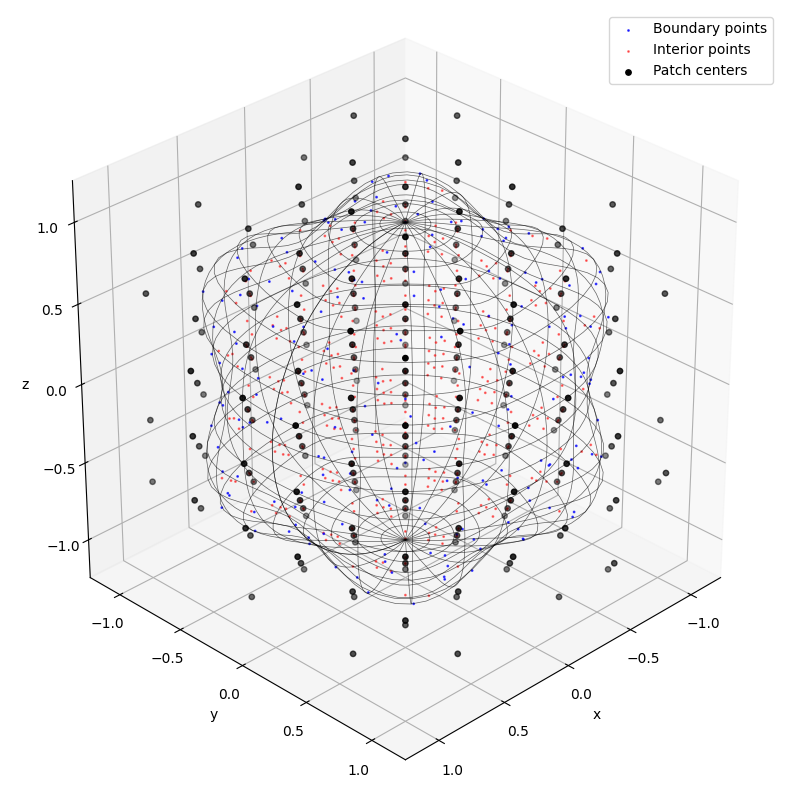

My fill distance is 0.25385276307020044


In [13]:
def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

# H_list = [2.02/k for k in range(5, 11)]  [0.404, 0.337, 0.289, 0.253, 0.224, 0.202]
H = 0.4
delta = 0.2
n_per_patch = 6
N_boundary = 200
X_inner, X_boundary, C, R_vec, info = generator_points_3d_H_delta( H, delta, n_per_patch, N_boundary, margin=0.15, remove_duplicates=False, visu=True, show_patches=False )
X = np.concatenate([X_inner,X_boundary],axis=0)
h = fill_distance(X)
print("My fill distance is", h)
# n: 5, in: 420, h = 0.23
# n: 10, in: 819 , h = 0.18
# n: 40, in: 3234, h = 0.12
# n: 70, in: 5638, h = 0.097
# n: 100, in: 8084, h = 0.086
# n: 200, in: 16116, h = 0.068

In [3]:
import numpy as np
import torch
import torch.nn as nn
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.spatial import KDTree, distance
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve,splu, eigs, LinearOperator, svds
from scipy.linalg import lstsq, lu_factor, lu_solve
from scipy.sparse import csc_matrix
import matplotlib.ticker as ticker
import time
dtype = torch.float64
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)


import numpy as np
from scipy.spatial import cKDTree


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(2.480142735337281)**2 * x**2)
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, 0, 0)
                    # nn.init.uniform_(m.bias, -torch.pi, -torch.pi)


def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    # plt.savefig('L.eps', bbox_inches='tight')
    plt.show()

def wendland_C2(r):
    return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r)**4

def wendland_C2_derivatives_3d(r, diff, R):
    """
    Delta phi(r_scaled) = 1/R^2 * [phi''(r_scaled)] + 2/r_scaled * phi'(r_scaled)]
    r:    (M, Nc)
    diff: (M, Nc, 3)
    R:    (Nc,)
    """
    eps = 1e-8
    M, Nc = r.shape
    mask = (r < 1).astype(float)
    phi_r_prime  = -20.0 * r * (1.0 - r)**3 * mask
    phi_r_double =  20.0 * (1.0 - r)**2 * (4.0*r - 1.0) * mask
    diff_norm = np.linalg.norm(diff, axis=2)
    diff_norm = np.maximum(diff_norm, eps)
    grad = np.zeros_like(diff)
    lap = np.zeros((M, Nc))
    for j in range(Nc):
        grad[:, j, :] = (
            phi_r_prime[:, j] / (diff_norm[:, j] * R[j])
        )[:, None] * diff[:, j, :]
        lap[:, j] = (
            phi_r_double[:, j]
            + 2.0 * phi_r_prime[:, j] / (r[:, j] + eps)
        ) / (R[j]**2)
    return grad, lap

def shepard_weights_with_derivatives_3d(x, ptch_C, ptch_R):
    """
    x:(M,3) ptch_C:(Np,3), ptch_R:(Np,)
    return
    (M,Np), (M,Np,3), (M,Np)
    """
    eps = 1e-12
    diff = x[:, None, :] - ptch_C[None, :, :]   # (M, Nc, 3)
    r_dist = np.linalg.norm(diff, axis=2)
    r_scaled = r_dist / ptch_R[None, :]
    phi = wendland_C2(r_scaled)
    sum_phi = np.sum(phi, axis=1, keepdims=True)
    sum_phi = np.maximum(sum_phi, 1e-8)
    W = phi / sum_phi
    # ===== 导数 =====
    grad_phi, lap_phi = wendland_C2_derivatives_3d(r_scaled, diff, ptch_R)
    # S = sum_j phi_j
    S = np.sum(phi, axis=1, keepdims=True)           # (M, 1)
    S = np.maximum(S, eps)
    # grad S, lap S
    grad_S = np.sum(grad_phi, axis=1, keepdims=True) # (M, 1, 3)
    lap_S = np.sum(lap_phi, axis=1, keepdims=True)   # (M, 1)
    # W_j = phi_j / S
    W = phi / S                                      # (M, Np)
    # ===== ∇W =====
    # grad W_j = grad_phi_j / S - phi_j grad_S / S^2
    grad_W = (grad_phi / S[:, :, None] - phi[:, :, None] * grad_S / (S[:, :, None] ** 2))
    # ===== ΔW =====
    # lap W_j = lap_phi_j / S - phi_j lap_S / S^2- 2 grad_phi_j · grad_S / S^2 + 2 phi_j |grad_S|^2 / S^3
    grad_phi_dot_grad_S = np.sum(grad_phi * grad_S,axis=2)   # (M, Np)
    grad_S_norm2 = np.sum(grad_S[:, 0, :] ** 2,axis=1,keepdims=True)  
    lap_W = (lap_phi / S- phi * lap_S / (S ** 2)- 2.0 * grad_phi_dot_grad_S / (S ** 2)+ 2.0 * phi * grad_S_norm2 / (S ** 3))
    return W, grad_W, lap_W

def dphi_wrt_y_3d_batch(phi_net, y, X, eps=1e-8):
    """
    1D Parameters
    ----------
    y : (n_j,3) or (1,3)
    X : (K,3)
    
    Returns
    -------
    phi_vals : (n_j, K)
    dphi_dy  : (n_j, K)
    d2phi_dy2: (n_j, K)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    # print("y.shape", y.shape, "X.shape", X.shape)
    y.requires_grad_(False)
    X.requires_grad_(False)
    # =========================================================
    # 1. pairwise difference and Euclidean distance
    # =========================================================
    diff = y[:, None, :] - X[None, :, :]          # (n_j, K, 3)
    r = torch.sqrt((diff ** 2).sum(dim=-1))  # (n_j, K)
    r = r.clamp(min=eps)  
    r.requires_grad_(True)
    # -------- forward --------
    phi_vals = phi_net(r)         # (n_j, K)

    # -------- φ'(r) --------
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True,
    )[0]   # (n_j, K)
    # -------- φ''(r) --------
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=False,
    )[0]   # (n_j, K)
    # 3d laplace
    with torch.no_grad():
        grad_phi = dphi_dr[..., None] * diff / r[..., None]
        lap_phi = d2phi_dr2 + (2.0 / (r)) * dphi_dr
        phi_np = phi_vals.detach().cpu().numpy()
        grad_np = grad_phi.detach().cpu().numpy()
        lap_np = lap_phi.detach().cpu().numpy()
        
    del diff, r, phi_vals, dphi_dr, d2phi_dr2, grad_phi, lap_phi

    if device.type == "cuda":
        torch.cuda.empty_cache()
    return phi_np, grad_np, lap_np


def dphi_wrt_y_3d_chunked(phi_net, Yj, Xj, chunk_size=256):
    phi_list = []
    grad_list = []
    lap_list = []
    for start in range(0, Yj.shape[0], chunk_size):
        end = min(start + chunk_size, Yj.shape[0])
        y_chunk = Yj[start:end]   # (chunk, 3)
        phi, grad, lap = dphi_wrt_y_3d_batch(
            phi_net, y_chunk, Xj
        )
        phi_list.append(phi)
        grad_list.append(grad)
        lap_list.append(lap)
    phi = np.vstack(phi_list)
    grad = np.vstack(grad_list)
    lap = np.vstack(lap_list)
    return phi, grad, lap


def poly3D(Z, order):
    """
    Z: (K, d)
    P: (K, Norder); 
    """
    K = Z.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    P = np.zeros((K, Norder))
    powers = np.arange(order + 1)
    X_pow = Z[:, 0:1] ** powers
    Y_pow = Z[:, 1:2] ** powers
    Z_pow = Z[:, 2:3] ** powers
    cnt = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                P[:, cnt] = X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k]
                cnt += 1        
    return P

def laplacian_poly3D(y, order):
    """
    y: (Np, d)
    lap: (Norder, Np); 
    """
    Np = y.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    lap = np.zeros((Norder, Np))
    
    # 【核心优化】：同样预先计算 0 到 order 的所有幂次
    powers = np.arange(order + 1)
    X_pow = y[:, 0:1] ** powers
    Y_pow = y[:, 1:2] ** powers
    Z_pow = y[:, 2:3] ** powers
    curr = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                val = np.zeros(Np)
                if i >= 2:
                    val += (i * (i - 1)) * (X_pow[:, i - 2] * Y_pow[:, j] * Z_pow[:, k])
                if j >= 2:
                    val += (j * (j - 1)) * (X_pow[:, i] * Y_pow[:, j - 2] * Z_pow[:, k])
                if k >= 2:
                    val += (k * (k - 1)) * (X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k - 2]) 
                lap[curr, :] = val
                curr += 1     
    return lap

def gradient_poly3D(y,order):
    """
    Parameters
    ----------
    y : (M, 3)
    Returns
    -------
    grad_x : (Norder, M)
    grad_y : (Norder, M)
    grad_z : (Norder, M)
    """
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]  # (1,3)
    M = y.shape[0]
    x = y[:, 0]
    yv = y[:, 1]
    z = y[:, 2]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    grad_x = np.zeros((Norder, M))
    grad_y = np.zeros((Norder, M))
    grad_z = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            for k in range(order + 1 - i - j):
                # ∂/∂x
                if i == 0:
                    grad_x[idx, :] = 0.0
                else:
                    grad_x[idx, :] = i * (x ** (i - 1)) * (yv ** j) * (z ** k)
                # ∂/∂y
                if j == 0:
                    grad_y[idx, :] = 0.0
                else:
                    grad_y[idx, :] = j * (x ** i) * (yv ** (j - 1)) * (z ** k)
                # ∂/∂z
                if k == 0:
                    grad_z[idx, :] = 0.0
                else:
                    grad_z[idx, :] = k * (x ** i) * (yv ** j) * (z ** (k - 1))
                idx += 1
    return grad_x, grad_y, grad_z

def rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order):
    """
    -Laplace(u) - k^2 u = f, where k^2 = 1
    X:  (N,3)  RBF source points
    Yin: (M1,3) interior points
    Yb:  (M2,3) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0,1,2,3...
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    Y = np.vstack((Yin, Yb))
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    Np = patch_C.shape[0]
    
    f_val =f_func(Yin[:, 0], Yin[:, 1], Yin[:, 2])  if callable(f_func) else f_func #(M1,)
    g_val = g_func(Yb[:, 0], Yb[:, 1], Yb[:, 2]) if callable(g_func) else g_func
    RHS = np.concatenate((f_val, g_val)) #(M,)
    # print("RHS.shape",RHS.shape)
    L = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    O = np.zeros((Norder,Norder))
    # ==============================
    # main loop
    # ==============================
    tree_X = cKDTree(X)
    tree_Y = cKDTree(Y)

    W, grad_W, lap_W= shepard_weights_with_derivatives_3d(Y, patch_C, patch_R)
    # print("W.shape",W.shape)
    grad_Wx, grad_Wy, grad_Wz = grad_W[:,:,0], grad_W[:,:,1], grad_W[:,:,2]

    start = time.time()
    for j in range(Np):
        idx_X = np.array(tree_X.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
        idx_Y = np.array(tree_Y.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
        idx_X.sort()
        idx_Y.sort()
        idx_Yin = idx_Y[idx_Y<M1]
        idx_Yb =  idx_Y[idx_Y>=M1]

        nj   = idx_X.shape[0]
        Mk   = idx_Y.shape[0]
        Mk1  = idx_Yin.shape[0]
        Mk2  = idx_Yb.shape[0]
        Xj   = X[idx_X]
        Yj   = Y[idx_Y]
        Yj_in = Y[idx_Yin]
        # print(idx_Y.shape,idx_X.shape, idx_Yb.shape)
        dist_ZZ = distance.cdist(Xj, Xj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        # 内存不够, 分块计算导数
        if Yj.shape[0] * Xj.shape[0] >= 2e5:
            phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_chunked(Phi, Yj, Xj, chunk_size=800)
        else:
            phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_batch(Phi, Yj, Xj, eps=1e-8) # (Mk,nj),(Mk,nj,3),(Mk,nj),
        # print("phi_xj",phi_xj.shape,"lap_phi",lap_phi.shape, "grad_phi",grad_phi.shape)
        # if not drop:
        grad_phi_x = grad_phi[:Mk1, :, 0].T  # (nj,Mk1)
        grad_phi_y = grad_phi[:Mk1, :, 1].T  # (nj,Mk1)
        grad_phi_z = grad_phi[:Mk1, :, 2].T  # (nj,Mk1)

        # AP
        P = poly3D(Xj, order) # (nj,Norder)
        # print("Phi_jj.shape",Phi_jj.shape, "P.shape", P.shape)
        AP = np.block([
            [Phi_jj, P],
            [P.T, O]
        ])
        AP += reg * np.eye(nj + Norder)
        
        # RHS_lap, RHS_ide
        p_y = poly3D(Yj, order)                  # (Mk,Norder)
        lap_p = laplacian_poly3D(Yj_in, order)   # (Norder,Mk1)
        # print("p_y.shape",p_y.shape, "lap_p",lap_p.shape)
        RHS_lap = np.concatenate((lap_phi[:Mk1,:], lap_p.T), axis = 1).T  # (nj+Norder,Mk1)
        # print(RHS_lap.shape)
        RHS_ide = np.concatenate((phi_xj, p_y), axis = 1).T       # (nj+Norder,Mk)
        # RHS_grad
        grad_p_x,grad_p_y,grad_p_z = gradient_poly3D(Yj_in, order)  # (Norder,Mk1)
        # if not drop:
        RHS_grad_x = np.concatenate((grad_phi_x, grad_p_x), axis = 0) # (nj+Norder,Mk1)
        RHS_grad_y = np.concatenate((grad_phi_y, grad_p_y), axis = 0) # (nj+Norder,Mk1)
        RHS_grad_z = np.concatenate((grad_phi_z, grad_p_z), axis = 0) # (nj+Norder,Mk1)
        RHS_all = np.concatenate((RHS_lap,RHS_ide,RHS_grad_x,RHS_grad_y,RHS_grad_z),axis=1)       # (nj+Norder,Mk1+Mk+Mk1+Mk1+MK1)
        # else:
        #     RHS_all = np.concatenate((RHS_lap,RHS_ide),axis=1) # (nj+Norder,Mk1+Mk)
        # local operator weight
        LU = lu_factor(AP)
        w_all = lu_solve(LU, RHS_all)                 # (nj + Norder, Mk)
        w_lap = w_all[:, :Mk1]
        w_ide = w_all[:, Mk1:Mk1+Mk]
        # if not drop:
        w_grad_x = w_all[:, Mk1+Mk:2*Mk1+Mk]
        w_grad_y = w_all[:, 2*Mk1+Mk:3*Mk1+Mk]
        w_grad_z = w_all[:, 3*Mk1+Mk:]
        # Shepard weight
        win = W[idx_Yin,j][None, :]  # (1, Mk1)
        # if not drop:
        win_gradx = grad_Wx[idx_Yin,j][None, :]  # (1, Mk1)
        win_grady = grad_Wy[idx_Yin,j][None, :]  # (1, Mk1)
        win_gradz = grad_Wz[idx_Yin,j][None, :]  # (1, Mk1)
        win_lap = lap_W[idx_Yin,j][None, :]      # (1, Mk1)
        # Laplace (nj,Mk1)
        # if not drop:
        Laplace = (2 * win_gradx * w_grad_x[:nj,:Mk1]+ 2 * win_grady * w_grad_y[:nj,:Mk1] + 2 * win_gradz * w_grad_z[:nj,:Mk1] + win * w_lap[:nj,:Mk1] + win_lap * w_ide[:nj,:Mk1])  # (nj, Mk_1)
        # else: 
        # Laplace =  win * w_lap[:nj,:Mk1]
        I = win * w_ide[:nj,:Mk1]          # (nj, Mk1)
        # --- boundary condtion
        wbc = W[idx_Yb,j][None, :]     # (1, Mk2)
        Op_bc = wbc * w_ide[:nj,Mk1:]  # (nj, Mk2)
        # --- LI 
        wvec = W[idx_Y, j][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]      # (nj,Mk)

        L[np.ix_(idx_Yin, idx_X)] = L[np.ix_(idx_Yin, idx_X)] - Laplace.T - I.T
        L[np.ix_(idx_Yb, idx_X)] = L[np.ix_(idx_Yb, idx_X)] + Op_bc.T
        
        LI[np.ix_(idx_Y, idx_X)] = LI[np.ix_(idx_Y, idx_X)] + IDE.T

    end = time.time()
    print("Compile derivative matrix time =", end - start, "seconds")
        
    L = L.tocsc()
    LI = LI.tocsc()
    # cond_L = np.linalg.cond(L.tocsr().todense())
    # print(f" L's condition number:, {cond_L}")
    # cond_LI = np.linalg.cond(LI.tocsr().todense())
    # print(f" LI's condition number:, {cond_LI}")
    # spy_like_matlab(L)
    # ==============================
    # solve
    # ==============================

    if M == N:
        LU1 = splu(L, permc_spec='COLAMD')
        UX = LU1.solve(RHS)
    else:
        L_dense = L.toarray()
        UX, res, rank, s = lstsq(L_dense, RHS)
        print(f'rank = {rank}')
    UY = LI @ UX
    return UY[:,None],LI,L
# (M,1)


In [4]:
# import numpy as np
# from scipy.spatial import cKDTree

# def estimate_uniform_R_from_target_n(X, target_n, safety=1.1):
#     """
#     根据目标 patch 内点数 target_n，估计统一半径 R。
#     用每个点到第 target_n 个邻居的距离，再取中位数。
#     """
#     tree = cKDTree(X)
#     target_n = min(target_n, X.shape[0])
#     dists, _ = tree.query(X, k=target_n, workers=-1)
#     if target_n == 1:
#         r_each = dists
#     else:
#         r_each = dists[:, -1]
#     R = safety * np.median(r_each)
#     return R

# def generate_centers_from_R(X, R, delta=0.2, margin=0.1):
#     """
#     根据统一半径 R 生成规则 Cartesian patch centers。
#     3D 中:
#         R = (1 + delta) * sqrt(3) * H / 2
#     所以:
#         H = 2R / ((1 + delta) sqrt(3))
#     """
#     H = 2.0 * R / ((1.0 + delta) * np.sqrt(3.0))
#     xmin, ymin, zmin = X.min(axis=0) - margin
#     xmax, ymax, zmax = X.max(axis=0) + margin
#     gx = np.arange(xmin, xmax + H, H)
#     gy = np.arange(ymin, ymax + H, H)
#     gz = np.arange(zmin, zmax + H, H)
#     Xg, Yg, Zg = np.meshgrid(gx, gy, gz, indexing="ij")
#     C_all = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T
#     return C_all, H



# def filter_centers_touching_X(C_all, X, R):
#     """
#     只保留半径 R 内至少包含一个 X 点的 patch center。
#     """
#     tree_X = cKDTree(X)
#     keep = []
#     for i, c in enumerate(C_all):
#         idx = tree_X.query_ball_point(c, R)
#         if len(idx) > 0:
#             keep.append(i)
#     return C_all[np.array(keep, dtype=int)]


# def check_patch_cover_and_counts(C, R, X):
#     """
#     因为 X=Y，所以检查所有 X 是否被至少一个 patch 覆盖，
#     并统计每个 patch 内点数。
#     """
#     tree_C = cKDTree(C)
#     cover_lists = tree_C.query_ball_point(X, R)
#     cover_count = np.array([len(v) for v in cover_lists])
#     uncovered = np.where(cover_count == 0)[0]
#     tree_X = cKDTree(X)
#     nX = np.array([len(tree_X.query_ball_point(c, R)) for c in C])
#     print("========== Patch report ==========")
#     print("num patches:", len(C))
#     print("R =", R)
#     print("uncovered X:", len(uncovered), "/", len(X))
#     print("cover count min/mean/max:",
#           cover_count.min(), cover_count.mean(), cover_count.max())
#     print("patch nX min/mean/max:",
#           nX.min(), nX.mean(), nX.max())
#     return uncovered, cover_count, nX

# def generate_patches_X_equals_Y(
#     X,
#     target_n=120,
#     delta=0.2,
#     safety=1.1,
#     margin=0.1,
#     max_iter=10
# ):
#     """
#     X=Y 情况下，根据每个 patch 目标点数 target_n 生成 C 和统一 R。
#     """
#     X = np.asarray(X)
#     # 1. 由目标点数估计统一半径
#     R = estimate_uniform_R_from_target_n(
#         X,
#         target_n=target_n,
#         safety=safety
#     )
#     for it in range(max_iter):
#         print(f"\n--- iter {it} ---")

#         # 2. 由 R 反推中心网格
#         C_all, H = generate_centers_from_R(
#             X,
#             R,
#             delta=delta,
#             margin=margin
#         )
#         # 3. 保留和 X 有交集的 patch
#         C = filter_centers_touching_X(C_all, X, R)
#         # 4. 检查覆盖
#         uncovered, cover_count, nX = check_patch_cover_and_counts(C, R, X)
#         print("H =", H)
#         print("target_n =", target_n)
#         print("mean nX / target_n =", nX.mean() / target_n)
#         if len(uncovered) == 0:
#             break
#         # 如果没覆盖完整，扩大半径
#         R *= 1.05
#     R_vec = R * np.ones(len(C))
#     info = {
#         "R": R,
#         "H": H,
#         "delta": delta,
#         "num_patches": len(C),
#         "target_n": target_n,
#         "nX_min": nX.min(),
#         "nX_mean": nX.mean(),
#         "nX_max": nX.max(),
#         "cover_min": cover_count.min(),
#         "cover_mean": cover_count.mean(),
#         "cover_max": cover_count.max(),
#         "uncovered": len(uncovered),
#     }
#     return C, R_vec, info
# ## fixed H
# import numpy as np
# from scipy.spatial import cKDTree


# def estimate_uniform_R_from_target_n(X, target_n, safety=1.1):
#     tree = cKDTree(X)
#     target_n = min(target_n, X.shape[0])

#     dists, _ = tree.query(X, k=target_n, workers=-1)

#     if target_n == 1:
#         r_each = dists
#     else:
#         r_each = dists[:, -1]

#     R = safety * np.median(r_each)
#     return R


# def generate_centers_from_fixed_H(X, H, margin=0.1):
#     """
#     固定 patch center spacing H 生成规则 Cartesian centers.
#     """
#     xmin, ymin, zmin = X.min(axis=0) - margin
#     xmax, ymax, zmax = X.max(axis=0) + margin

#     gx = np.arange(xmin, xmax + H, H)
#     gy = np.arange(ymin, ymax + H, H)
#     gz = np.arange(zmin, zmax + H, H)

#     Xg, Yg, Zg = np.meshgrid(gx, gy, gz, indexing="ij")
#     C_all = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T

#     return C_all


# def filter_centers_touching_X(C_all, X, R):
#     tree_X = cKDTree(X)

#     keep = []
#     for i, c in enumerate(C_all):
#         idx = tree_X.query_ball_point(c, R)
#         if len(idx) > 0:
#             keep.append(i)

#     return C_all[np.array(keep, dtype=int)]


# def check_patch_cover_and_counts(C, R, X):
#     tree_C = cKDTree(C)
#     cover_lists = tree_C.query_ball_point(X, R)

#     cover_count = np.array([len(v) for v in cover_lists])
#     uncovered = np.where(cover_count == 0)[0]

#     tree_X = cKDTree(X)
#     nX = np.array([len(tree_X.query_ball_point(c, R)) for c in C])

#     print("========== Patch report ==========")
#     print("num patches:", len(C))
#     print("R =", R)
#     print("uncovered X:", len(uncovered), "/", len(X))
#     print("cover count min/mean/max:",
#           cover_count.min(), cover_count.mean(), cover_count.max())
#     print("patch nX min/mean/max:",
#           nX.min(), nX.mean(), nX.max())

#     return uncovered, cover_count, nX


# def generate_patches_X_equals_Y_fixed_H(
#     X,
#     H,
#     target_n=120,
#     safety=1.1,
#     margin=0.1,
#     max_iter=10,
#     grow_R_if_uncovered=True
# ):
#     """
#     固定 H，根据 target_n 估计统一 R，然后生成 PoU patches.

#     X:        (N,3)
#     H:        patch center spacing，固定
#     target_n: 希望每个 patch 内平均包含的点数
#     """

#     X = np.asarray(X)

#     # 1. 根据目标点数估计统一半径 R
#     R = estimate_uniform_R_from_target_n(
#         X,
#         target_n=target_n,
#         safety=safety
#     )

#     # 2. 固定 H 生成 centers
#     C_all = generate_centers_from_fixed_H(
#         X,
#         H=H,
#         margin=margin
#     )

#     for it in range(max_iter):
#         print(f"\n--- iter {it} ---")
#         # 3. 只保留非空 patch
#         C = filter_centers_touching_X(C_all, X, R)
#         # 4. 检查覆盖和每个 patch 点数
#         uncovered, cover_count, nX = check_patch_cover_and_counts(C, R, X)
#         delta_like = 2.0 * R / (np.sqrt(3.0) * H) - 1.0
#         overlap_factor = 2.0 * R / H
#         print("H =", H)
#         print("target_n =", target_n)
#         print("mean nX / target_n =", nX.mean() / target_n)
#         print("equivalent delta_like =", delta_like)
#         if len(uncovered) == 0:
#             break
#         if not grow_R_if_uncovered:
#             break
#         # 如果固定 H 下覆盖不全，只扩大 R
#         R *= 1.05

#     R_vec = R * np.ones(len(C))

#     info = {
#         "R": R,
#         "H": H,
#         "num_patches": len(C),
#         "target_n": target_n,
#         "equivalent_delta_like": 2.0 * R / (np.sqrt(3.0) * H) - 1.0,
#         "nX_min": nX.min(),
#         "nX_mean": nX.mean(),
#         "nX_max": nX.max(),
#         "cover_min": cover_count.min(),
#         "cover_mean": cover_count.mean(),
#         "cover_max": cover_count.max(),
#         "uncovered": len(uncovered),
#     }
#     return C, R_vec, info

In [5]:
# X = np.vstack([X_inner, X_boundary])   # 你的 X=Y

# # C_pou, R_pou, info = generate_patches_X_equals_Y(X,target_n=120,delta=0.2,
# #                                                  safety=1.1,margin=0.1)
# C_pou, R_pou, info = generate_patches_X_equals_Y_fixed_H(
#     X,
#     H=0.4,
#     target_n=150,
#     safety=1.1,
#     margin=0.1,
#     max_iter=10
# )

# ptch = {
#     "C": C_pou,
#     "R": R_pou
# }

# info["nX_mean"]
# info["nX_min"]
# info["nX_max"]
# info["cover_mean"]
# info["uncovered"]


In [6]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_pou_patch_cover_rQ(C, R, n_surface=80, n_sphere=24, show_centers=True):
#     """
#     C: (Np, 3) patch centers
#     R: (Np,) patch radii
#     """

#     C = np.asarray(C)
#     R = np.asarray(R)

#     fig = plt.figure(figsize=(9, 9))
#     ax = fig.add_subplot(111, projection='3d')

#     # =====================================================
#     # 1. plot true rQ boundary
#     # =====================================================
#     theta = np.linspace(0, 2*np.pi, n_surface)
#     phi = np.linspace(0, np.pi, n_surface)
#     theta, phi = np.meshgrid(theta, phi)

#     rq = rQ(theta, phi)

#     Xq = rq * np.sin(phi) * np.cos(theta)
#     Yq = rq * np.sin(phi) * np.sin(theta)
#     Zq = rq * np.cos(phi)

#     ax.plot_wireframe(
#         Xq, Yq, Zq,
#         rstride=3, cstride=3,
#         color='black',
#         linewidth=0.6,
#         alpha=0.8,
#         label=r'$r_Q$ boundary'
#     )

#     # =====================================================
#     # 2. plot patch spheres
#     # =====================================================
#     us = np.linspace(0, 2*np.pi, n_sphere)
#     vs = np.linspace(0, np.pi, n_sphere)
#     us, vs = np.meshgrid(us, vs)

#     sphere_x = np.sin(vs) * np.cos(us)
#     sphere_y = np.sin(vs) * np.sin(us)
#     sphere_z = np.cos(vs)

#     for j in range(len(C)):
#         x = C[j, 0] + R[j] * sphere_x
#         y = C[j, 1] + R[j] * sphere_y
#         z = C[j, 2] + R[j] * sphere_z

#         ax.plot_wireframe(
#             x, y, z,
#             rstride=4, cstride=4,
#             color='tab:blue',
#             linewidth=0.35,
#             alpha=0.18
#         )

#     # =====================================================
#     # 3. centers
#     # =====================================================
#     if show_centers:
#         ax.scatter(
#             C[:, 0], C[:, 1], C[:, 2],
#             s=18,
#             color='tab:red',
#             depthshade=True,
#             label='patch centers'
#         )

#     # =====================================================
#     # 4. visual settings
#     # =====================================================
#     ax.set_box_aspect([1, 1, 1])

#     lim = 1.5
#     ax.set_xlim([-lim, lim])
#     ax.set_ylim([-lim, lim])
#     ax.set_zlim([-lim, lim])

#     ax.set_xlabel('x')
#     ax.set_ylabel('y')
#     ax.set_zlabel('z')

#     ax.view_init(elev=28, azim=45)
#     ax.grid(True, alpha=0.3)
#     ax.legend(loc='upper right')

#     plt.tight_layout()
#     plt.show()

# plot_pou_patch_cover_rQ(C_pou, R_pou)

========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 230
n_per_patch: 100
X_inner: 8084
X_boundary: 3000
h_approx = H / n^(1/3) = 0.08617738760127536


/home/chengwu/.conda/envs/py312/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Compile derivative matrix time = 16.776681184768677 seconds
Time for solving Helm = 62.03046894073486 seconds
(11084, 1) (11084, 1)
p = 6; L infity error in u_rfmfd: 6.179e-02
p = 6; Relative L2 error in u_rfmfd: 2.228e-02


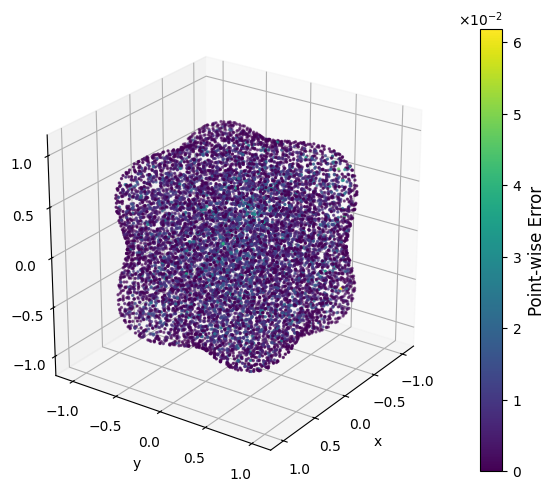

In [11]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double()
# #===========================================================

# # ===========================================================
u_func = lambda x, y, z: np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
f_func = lambda x, y, z: (3 * np.pi**2 - 1) * np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
g_func = lambda x, y, z: u_func(x, y, z)

torchdtype = torch.float64
# N_patch_grid = 5
# N_local_per_patch = 300
# N_boundary = 6000
# overlap = 0.6

# generate points
# X_inner, X_boundary, C, R = generator_points_3d_overlap(
#         N_patch_grid,
#         N_local_per_patch,
#         N_boundary,
#         overlap,
#         False
#     )
H = 0.4
delta = 0.2
n_per_patch = 100
N_boundary = 3000
X_inner, X_boundary, C, R_vec, info = generator_points_3d_H_delta( H, delta, n_per_patch, N_boundary, margin=0.15, remove_duplicates=False, visu=False, show_patches=False )
X = np.vstack([X_inner, X_boundary])
ptch = {
    "C": C,
    "R": R_vec
}
# C_pou, R_pou, info = generate_patches_X_equals_Y(X,target_n=300,delta=0.2,
#                                                  safety=1.1,margin=0.1)
# C_pou, R_pou, info = generate_patches_X_equals_Y_fixed_H(X,H=0.35,target_n=300,safety=1.1,margin=0.1,max_iter=10)
# ptch = {
#     "C": C_pou,
#     "R": R_pou
# }
# print(C,R)
X = np.vstack([X_inner, X_boundary])

Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
reg = 1e-13
order = 6
u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
# # ===========================================================
start = time.time()
UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg,order)
end = time.time()
print("Time for solving Helm =", end - start, "seconds")

print(u_true.shape,UY.shape)
error = np.abs(UY - u_true)
# print(error)
print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = relative_l2(UY ,u_true)
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u.item():.3e}')

import matplotlib.ticker as ticker
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=error,
    cmap='viridis',
    s=2
)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
# plt.savefig(f'./result/rfm_fd_p={order}_pointwise_error.eps', bbox_inches='tight')
plt.show()

In [12]:
h = fill_distance(X)
print("My fill distance is", h)

My fill distance is 0.08840648398598491


In [4]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double()
# #===========================================================

# # ===========================================================
u_func = lambda x, y, z: np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
f_func = lambda x, y, z: (3 * np.pi**2 - 1) * np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
g_func = lambda x, y, z: u_func(x, y, z)


key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

NN = [5, 10, 50, 100, 200]
BC = [300,600,3000, 4000, 8000]

start_order = 5
end_order = 10
overlap = 0.6
Length = end_order-start_order

HH = np.zeros((Length,len(NN)))
EE = np.zeros((Length,len(NN)))





In [ ]:
# key = 100
# np.random.seed(key)

# NN = [10, 40, 100, 200]
# BC = [400,1600,4000, 8000]

# start_order = 5
# end_order = 10
# Length = end_order-start_order

# for order in range(start_order,end_order):
#     for qi, n_local in enumerate(NN):
#         print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
#         # generate points
#         H = 0.4
#         delta = 0.2
#         n_per_patch = NN[qi]
#         N_boundary = BC[qi]
#         X_inner, X_boundary, C, R_vec, info = generator_points_3d_H_delta( H, delta, n_per_patch, N_boundary, margin=0.15, remove_duplicates=False, visu=False, show_patches=False )
#         X = np.vstack([X_inner, X_boundary])
#         ptch = {
#             "C": C,
#             "R": R_vec
#         }
#         Yin = X_inner
#         Yb = X_boundary
#         Y = np.vstack([Yin, Yb])
#         M1 = Yin.shape[0]
#         h = fill_distance(X)
#         h_approx = H/(n_per_patch)**(1/3)
#         print("my fill_distance is ", h)
#         print("approx fill_distance is ", h_approx)
#         reg = 1e-13
#         u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
#         UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
#         error = np.abs(UY[:M1,:] - u_true[:M1,:])
#         print(f'p = {order}; L infity error in u_rfmfd_pou: {error.max().item():.3e}')
#         error_u = relative_l2(UY[:M1,:] ,u_true[:M1,:])
#         print(f'p = {order}; Relative L2 error in u_rfmfd_pou: {error_u.item():.3e}')
#         EE[order-start_order,qi] = error_u
#         HH[order-start_order,qi] = h_approx


Run Q=1, N_local_per_patch=10
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 224
n_per_patch: 10
X_inner: 819
X_boundary: 400
h_approx = H / n^(1/3) = 0.18566355334451115
my fill_distance is  0.18927441507457193
approx fill_distance is  0.18566355334451115
Compile derivative matrix time = 1.0812146663665771 seconds
p = 5; L infity error in u_rfmfd_pou: 1.120e-01
p = 5; Relative L2 error in u_rfmfd_pou: 5.896e-02
Run Q=2, N_local_per_patch=40
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 230
n_per_patch: 40
X_inner: 3234
X_boundary: 1600
h_approx = H / n^(1/3) = 0.11696070952851466
my fill_distance is  0.126363053839526
approx fill_distance is  0.11696070952851466
Compile derivative matrix time = 3.7119076251983643 seconds
p = 5; L infity error in u_rfmfd_pou: 1.871e-01
p = 5; Relative L2 error in u_rfmfd_pou: 6.712e-02
Run Q=3, N_local_per

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


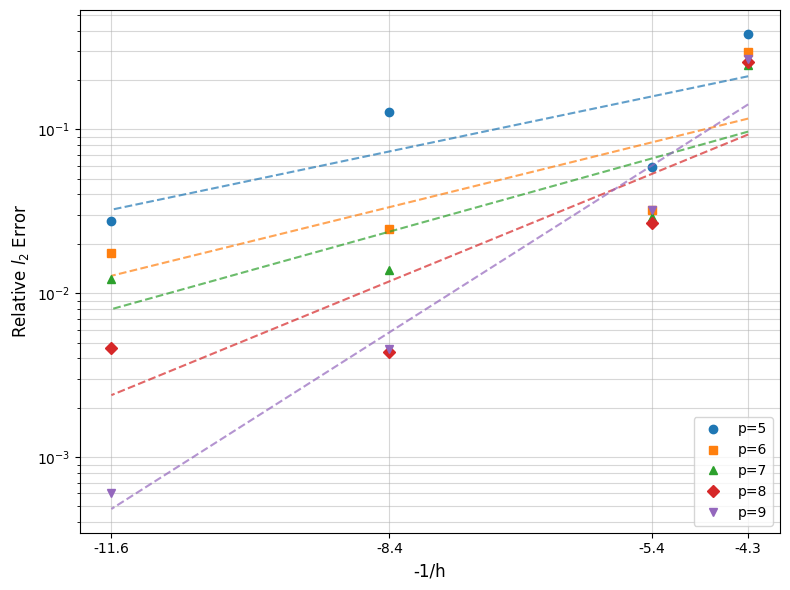

In [24]:
        

# markers = ['o', 's', '^', 'D', 'v']  
# colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
# labels = [f'p={start_order+0}', f'p={start_order+1}', f'p={start_order+2}', f'p={start_order+3}',f'p={start_order+4}']
# plt.figure(figsize=(8, 6))

# for i in range(end_order-start_order):
#     h = HH[i, :]
#     e = EE[i, :]

#     x = -1.0 / h   # h^{-1}
#     slope, intercept = np.polyfit(x, np.log(e), 1)
#     fit_e = np.exp(intercept + slope * x)
#     plt.semilogy(
#         x, e,
#         marker=markers[i],
#         linestyle='None',
#         color=colors[i],
#         label=f'{labels[i]}'
#     )
#     plt.semilogy(
#         x, fit_e,
#         linestyle='--',
#         color=colors[i],
#         alpha=0.7,
#         linewidth=1.5
#     )

# ax = plt.gca()
# xticks = -np.unique(1.0 / HH.ravel())
# xticks = xticks[np.isfinite(xticks)]
# xticks = np.sort(xticks)
# ax.set_xticks(xticks)

# ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.1f}"))
# plt.xlabel('-1/h', fontsize=12)
# plt.ylabel('Relative $l_2$ Error', fontsize=12)
# ax.xaxis.set_minor_locator(ticker.NullLocator())
# plt.grid(True, which="both", ls="-", alpha=0.5)
# plt.legend(loc='lower right')
# plt.tight_layout()

# plt.savefig('./result/helm3d_rfmfd_pou_p=56789_convergence_scatter_Hfixed.eps', bbox_inches='tight')
# plt.show()

# # plt.xlabel('Step size (h)', fontsize=12)
# # plt.ylabel('Relative $l_2$ Error', fontsize=12)
# # # plt.title('Convergence Study: Least Squares Fit', fontsize=14)
# # plt.grid(True, which="both", ls="-", alpha=0.5)
# # plt.legend(loc='lower right')
# # plt.tight_layout()
# # plt.savefig('./result/helm3d_rfmfd_pou_p=56789_convergence_scatter.eps', bbox_inches='tight')
# # plt.show()





Run Q=1, N_local_per_patch=10
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 224
n_per_patch: 10
X_inner: 819
X_boundary: 400
h_approx = H / n^(1/3) = 0.18566355334451115
my fill_distance is  0.18927441507457193
Compile derivative matrix time = 0.771963357925415 seconds
p = 5; L infity error in u_rfmfd_pou: 1.120e-01
p = 5; Relative L2 error in u_rfmfd_pou: 5.896e-02
Run Q=2, N_local_per_patch=40
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 230
n_per_patch: 40
X_inner: 3234
X_boundary: 2000
h_approx = H / n^(1/3) = 0.11696070952851466
my fill_distance is  0.126363053839526
Compile derivative matrix time = 3.535940170288086 seconds
p = 5; L infity error in u_rfmfd_pou: 7.106e-02
p = 5; Relative L2 error in u_rfmfd_pou: 3.693e-02
Run Q=3, N_local_per_patch=100
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.4156921938165305

/tmp/ipykernel_133342/1194695199.py:49: RuntimeWarning: divide by zero encountered in log10
  x = -np.log10(HH[row, :])
/tmp/ipykernel_133342/1194695199.py:50: RuntimeWarning: divide by zero encountered in log10
  y = -np.log10(EE[row, :])


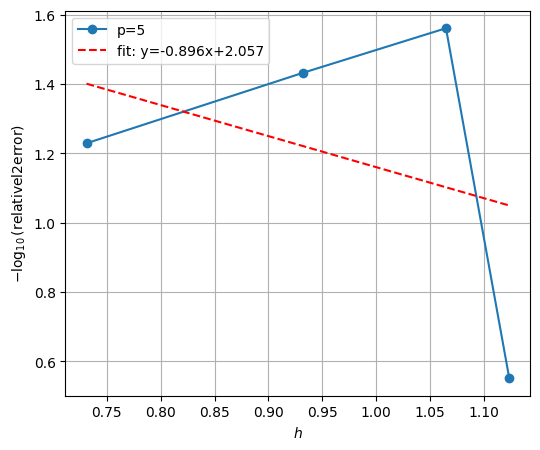

In [ ]:
key = 100
np.random.seed(key)
# 5 
# 200
NN = [ 6,10, 40, 100, ]
BC = [ ,400,2000,4000,]

start_order = 5
end_order = 10

Length = end_order-start_order

# H = np.zeros((Length,len(NN)))
# E = np.zeros((Length,len(NN)))

order = 5
row = order - start_order
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    # generate points
    H = 0.4
    delta = 0.2
    n_per_patch = NN[qi]
    N_boundary = BC[qi]
    X_inner, X_boundary, C, R_vec, info = generator_points_3d_H_delta( H, delta, n_per_patch, N_boundary, margin=0.15, remove_duplicates=False, visu=False, show_patches=False )
    X = np.vstack([X_inner, X_boundary])
    ptch = {
        "C": C,
        "R": R_vec
    }
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    M1 = Yin.shape[0]
    h = fill_distance(X)
    h_approx = H/(n_per_patch)**(1/3)
    print("my fill_distance is ", h)
    reg = 1e-13
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
    error = np.abs(UY[:M1,:] - u_true[:M1,:])
    print(f'p = {order}; L infity error in u_rfmfd_pou: {error.max().item():.3e}')
    error_u = relative_l2(UY[:M1,:] ,u_true[:M1,:])
    print(f'p = {order}; Relative L2 error in u_rfmfd_pou: {error_u.item():.3e}')
    EE[row,qi] = error_u
    HH[row,qi] = h_approx


x = -np.log10(HH[row, :])
y = -np.log10(EE[row, :])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$ h$')
    plt.ylabel(r'$-\log_{10}(\mathrm{relative l2 error})$')
    plt.legend()
    plt.grid(True)
    plt.show()


In [22]:
key = 100
np.random.seed(key)
# 5, 200 
NN = [10, 38, 100, 200]
BC = [400,1800,4000, 8000]

start_order = 5
end_order = 10

Length = end_order-start_order
row = order-start_order
order = 6
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    # generate points
    H = 0.4
    delta = 0.2
    n_per_patch = NN[qi]
    N_boundary = BC[qi]
    X_inner, X_boundary, C, R_vec, info = generator_points_3d_H_delta( H, delta, n_per_patch, N_boundary, margin=0.15, remove_duplicates=False, visu=False, show_patches=False )
    X = np.vstack([X_inner, X_boundary])
    ptch = {
        "C": C,
        "R": R_vec
    }
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    M1 = Yin.shape[0]
    h = fill_distance(X)
    h_approx = H/(n_per_patch)**(1/3)
    print("my fill_distance is ", h)
    print("approx fill_distance is ", h_approx)
    reg = 1e-13
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
    error = np.abs(UY[:M1,:] - u_true[:M1,:])
    print(f'p = {order}; L infity error in u_rfmfd_pou: {error.max().item():.3e}')
    error_u = relative_l2(UY[:M1,:] ,u_true[:M1,:])
    # error_u = np.linalg.norm(UY - u_true) / np.linalg.norm(u_true)
    print(f'p = {order}; Relative L2 error in u_rfmfd_pou: {error_u.item():.3e}')
    EE[row,qi] = error_u
    HH[row,qi] = h_approx


x = -np.log10(HH[row, :])
y = -np.log10(EE[row, :])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$ h$')
    plt.ylabel(r'$-\log_{10}(\mathrm{relative l2 error})$')
    plt.legend()
    plt.grid(True)
    plt.show()


Run Q=1, N_local_per_patch=5
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 215
n_per_patch: 5
X_inner: 420
X_boundary: 200
h_approx = H / n^(1/3) = 0.23392141905702932
my fill_distance is  0.25385276307020044
approx fill_distance is  0.23392141905702932
Compile derivative matrix time = 1.1926405429840088 seconds
p = 6; L infity error in u_rfmfd_pou: 9.876e-01
p = 6; Relative L2 error in u_rfmfd_pou: 2.963e-01
Run Q=2, N_local_per_patch=10
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 224
n_per_patch: 10
X_inner: 819
X_boundary: 400
h_approx = H / n^(1/3) = 0.18566355334451115
my fill_distance is  0.18927441507457193
approx fill_distance is  0.18566355334451115
Compile derivative matrix time = 1.0812537670135498 seconds
p = 6; L infity error in u_rfmfd_pou: 1.009e-01
p = 6; Relative L2 error in u_rfmfd_pou: 3.226e-02
Run Q=3, N_local_per_p

NameError: name 'row' is not defined

Run Q=1, N_local_per_patch=5
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 215
n_per_patch: 5
X_inner: 420
X_boundary: 200
h_approx = H / n^(1/3) = 0.23392141905702932
my fill_distance is  0.25385276307020044
approx fill_distance is  0.23392141905702932
Compile derivative matrix time = 1.1466262340545654 seconds
p = 7; L infity error in u_rfmfd_pou: 1.075e+00
p = 7; Relative L2 error in u_rfmfd_pou: 2.451e-01
Run Q=2, N_local_per_patch=10
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 224
n_per_patch: 10
X_inner: 819
X_boundary: 400
h_approx = H / n^(1/3) = 0.18566355334451115
my fill_distance is  0.18927441507457193
approx fill_distance is  0.18566355334451115
Compile derivative matrix time = 1.3803777694702148 seconds
p = 7; L infity error in u_rfmfd_pou: 1.380e-01
p = 7; Relative L2 error in u_rfmfd_pou: 2.925e-02
Run Q=3, N_local_per_p

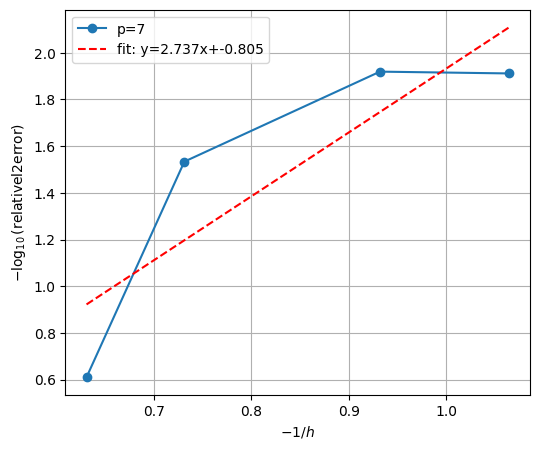

In [87]:
key = 100
np.random.seed(key)

NN = [5, 10, 40, 100]
BC = [200,400,2000,4000]

start_order = 5
end_order = 10

Length = end_order-start_order


order = 7
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    # generate points
    H = 0.4
    delta = 0.2
    n_per_patch = NN[qi]
    N_boundary = BC[qi]
    X_inner, X_boundary, C, R_vec, info = generator_points_3d_H_delta( H, delta, n_per_patch, N_boundary, margin=0.15, remove_duplicates=False, visu=False, show_patches=False )
    X = np.vstack([X_inner, X_boundary])
    ptch = {
        "C": C,
        "R": R_vec
    }
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    M1 = Yin.shape[0]
    h = fill_distance(X)
    h_approx = H/(n_per_patch)**(1/3)
    print("my fill_distance is ", h)
    print("approx fill_distance is ", h_approx)
    reg = 1e-13
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
    error = np.abs(UY[:M1,:] - u_true[:M1,:])
    print(f'p = {order}; L infity error in u_rfmfd_pou: {error.max().item():.3e}')
    error_u = relative_l2(UY[:M1,:] ,u_true[:M1,:])
    print(f'p = {order}; Relative L2 error in u_rfmfd_pou: {error_u.item():.3e}')
    EE[order-start_order,qi] = error_u
    HH[order-start_order,qi] = h_approx


row = order - start_order
x = -np.log10(HH[row, :])
y = -np.log10(EE[row, :])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$ h$')
    plt.ylabel(r'$-\log_{10}(\mathrm{relative l2 error})$')
    plt.legend()
    plt.grid(True)
    plt.show()


Run Q=1, N_local_per_patch=5
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 215
n_per_patch: 5
X_inner: 420
X_boundary: 200
h_approx = H / n^(1/3) = 0.23392141905702932
my fill_distance is  0.25385276307020044
approx fill_distance is  0.23392141905702932
Compile derivative matrix time = 1.1007428169250488 seconds
p = 8; L infity error in u_rfmfd_pou: 1.161e+00
p = 8; Relative L2 error in u_rfmfd_pou: 2.575e-01
Run Q=2, N_local_per_patch=10
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 224
n_per_patch: 10
X_inner: 819
X_boundary: 400
h_approx = H / n^(1/3) = 0.18566355334451115
my fill_distance is  0.18927441507457193
approx fill_distance is  0.18566355334451115
Compile derivative matrix time = 1.5231187343597412 seconds
p = 8; L infity error in u_rfmfd_pou: 1.119e-01
p = 8; Relative L2 error in u_rfmfd_pou: 2.672e-02
Run Q=3, N_local_per_p

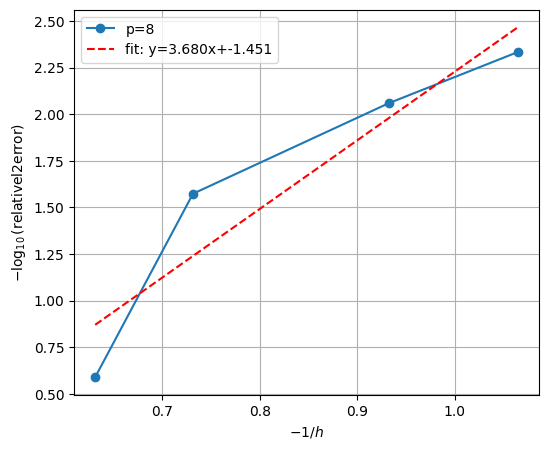

In [91]:
key = 100
np.random.seed(key)

NN = [5, 10, 40, 100]
BC = [200,400,2000,4000]

start_order = 5
end_order = 10

Length = end_order-start_order

order = 8
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    # generate points
    H = 0.4
    delta = 0.2
    n_per_patch = NN[qi]
    N_boundary = BC[qi]
    X_inner, X_boundary, C, R_vec, info = generator_points_3d_H_delta( H, delta, n_per_patch, N_boundary, margin=0.15, remove_duplicates=False, visu=False, show_patches=False )
    X = np.vstack([X_inner, X_boundary])
    ptch = {
        "C": C,
        "R": R_vec
    }
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    M1 = Yin.shape[0]
    h = fill_distance(X)
    h_approx = H/(n_per_patch)**(1/3)
    print("my fill_distance is ", h)
    print("approx fill_distance is ", h_approx)
    reg = 1e-13
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
    error = np.abs(UY[:M1,:] - u_true[:M1,:])
    print(f'p = {order}; L infity error in u_rfmfd_pou: {error.max().item():.3e}')
    error_u = relative_l2(UY[:M1,:] ,u_true[:M1,:])
    print(f'p = {order}; Relative L2 error in u_rfmfd_pou: {error_u.item():.3e}')
    EE[order-start_order,qi] = error_u
    HH[order-start_order,qi] = h_approx


row = order - start_order
x = -np.log10(HH[row, :])
y = -np.log10(EE[row, :])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$ h$')
    plt.ylabel(r'$-\log_{10}(\mathrm{relative l2 error})$')
    plt.legend()
    plt.grid(True)
    plt.show()


Run Q=1, N_local_per_patch=5
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 215
n_per_patch: 5
X_inner: 420
X_boundary: 200
h_approx = H / n^(1/3) = 0.23392141905702932
my fill_distance is  0.25385276307020044
approx fill_distance is  0.23392141905702932
Compile derivative matrix time = 1.8238437175750732 seconds
p = 9; L infity error in u_rfmfd_pou: 1.132e+00
p = 9; Relative L2 error in u_rfmfd_pou: 2.680e-01
Run Q=2, N_local_per_patch=10
========== Generator report ==========
H = 0.4
delta = 0.2
R = 0.41569219381653055
raw centers: 343
valid patch centers: 224
n_per_patch: 10
X_inner: 819
X_boundary: 400
h_approx = H / n^(1/3) = 0.18566355334451115
my fill_distance is  0.18927441507457193
approx fill_distance is  0.18566355334451115
Compile derivative matrix time = 2.937692403793335 seconds
p = 9; L infity error in u_rfmfd_pou: 1.132e-01
p = 9; Relative L2 error in u_rfmfd_pou: 3.201e-02
Run Q=3, N_local_per_pa

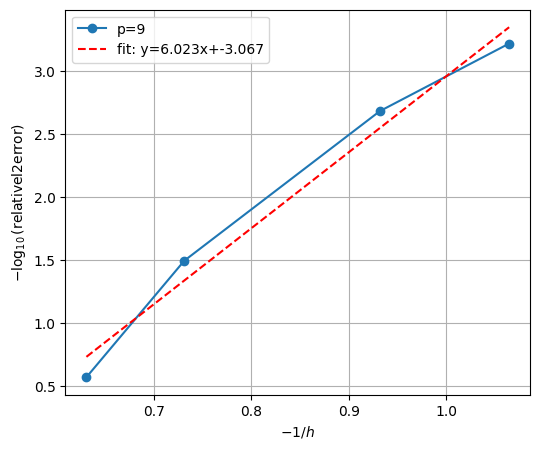

In [92]:
key = 100
np.random.seed(key)

NN = [5, 10, 40, 100]
BC = [200,400,2000,4000]

start_order = 5
end_order = 10

Length = end_order-start_order

order = 9
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    # generate points
    H = 0.4
    delta = 0.2
    n_per_patch = NN[qi]
    N_boundary = BC[qi]
    X_inner, X_boundary, C, R_vec, info = generator_points_3d_H_delta( H, delta, n_per_patch, N_boundary, margin=0.15, remove_duplicates=False, visu=False, show_patches=False )
    X = np.vstack([X_inner, X_boundary])
    ptch = {
        "C": C,
        "R": R_vec
    }
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    M1 = Yin.shape[0]
    h = fill_distance(X)
    h_approx = H/(n_per_patch)**(1/3)
    print("my fill_distance is ", h)
    print("approx fill_distance is ", h_approx)
    reg = 1e-13
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
    error = np.abs(UY[:M1,:] - u_true[:M1,:])
    print(f'p = {order}; L infity error in u_rfmfd_pou: {error.max().item():.3e}')
    error_u = relative_l2(UY[:M1,:] ,u_true[:M1,:])
    print(f'p = {order}; Relative L2 error in u_rfmfd_pou: {error_u.item():.3e}')
    EE[order-start_order,qi] = error_u
    HH[order-start_order,qi] = h_approx


row = order - start_order
x = -np.log10(HH[row, :])
y = -np.log10(EE[row, :])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$-1/h$')
    plt.ylabel(r'$-\log_{10}(\mathrm{relative l2 error})$')
    plt.legend()
    plt.grid(True)
    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


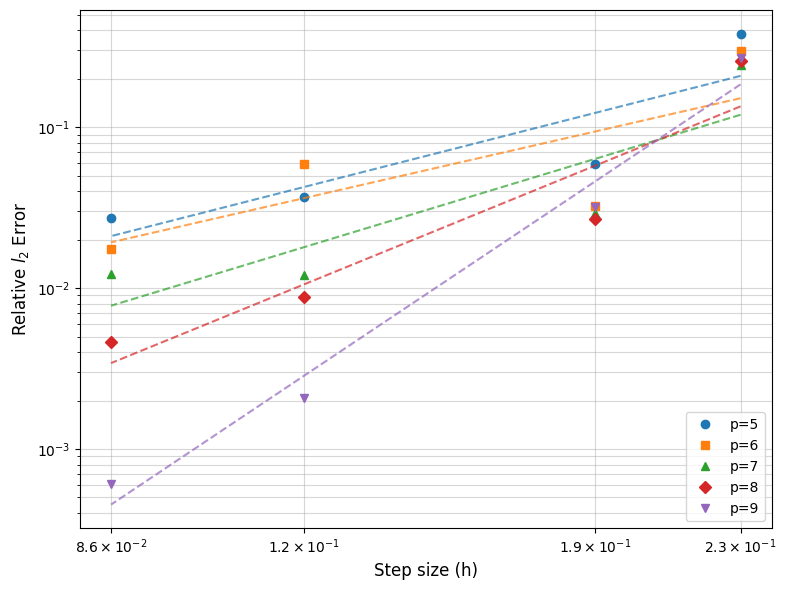

In [95]:
markers = ['o', 's', '^', 'D', 'v']  
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = [f'p={start_order+0}', f'p={start_order+1}', f'p={start_order+2}', f'p={start_order+3}',f'p={start_order+4}']
plt.figure(figsize=(8, 6))

for i in range(Length):
    h = HH[i, :]
    e = EE[i, :]
    log_h = np.log(h)
    log_e = np.log(e)
    slope, intercept = np.polyfit(log_h, log_e, 1)
    fit_e = np.exp(intercept) * h**slope
    plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]}')
    plt.loglog(h, fit_e, linestyle='--', color=colors[i], alpha=0.7)
    # plt.plot(h, e, marker=markers[i], color=colors[i], linestyle='-', label=f'{labels[i]}')
    # x = 1.0 / h   # h^{-1}
    # slope, intercept = np.polyfit(x, np.log(e), 1)
    # fit_e = np.exp(intercept + slope * x)
    # plt.semilogy(
    #     x, e,
    #     marker=markers[i],
    #     linestyle='-',
    #     color=colors[i],
    #     linewidth=1.5,
    #     label=f'{labels[i]}'
    # )
    # plt.semilogy(
    #     x, fit_e,
    #     linestyle='--',
    #     color=colors[i],
    #     alpha=0.7,
    #     linewidth=1.5
    # )

ax = plt.gca()
xticks = np.unique(HH.ravel())
xticks = xticks[np.isfinite(xticks)]
xticks = np.sort(xticks)
ax.set_xticks(xticks)
def sci_fmt(x, pos):
    if x == 0:
        return '0'
    exp = int(np.floor(np.log10(x)))
    coeff = x / 10**exp
    return r'$%.1f\times 10^{%d}$' % (coeff, exp)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(sci_fmt))
plt.xlabel('Step size (h)', fontsize=12)
plt.ylabel('Relative $l_2$ Error', fontsize=12)
ax.xaxis.set_minor_locator(ticker.NullLocator())
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('./result/helm3d_rfmfd_pou_p=56789_convergence_scatter_Hfixed_hp.eps', bbox_inches='tight')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


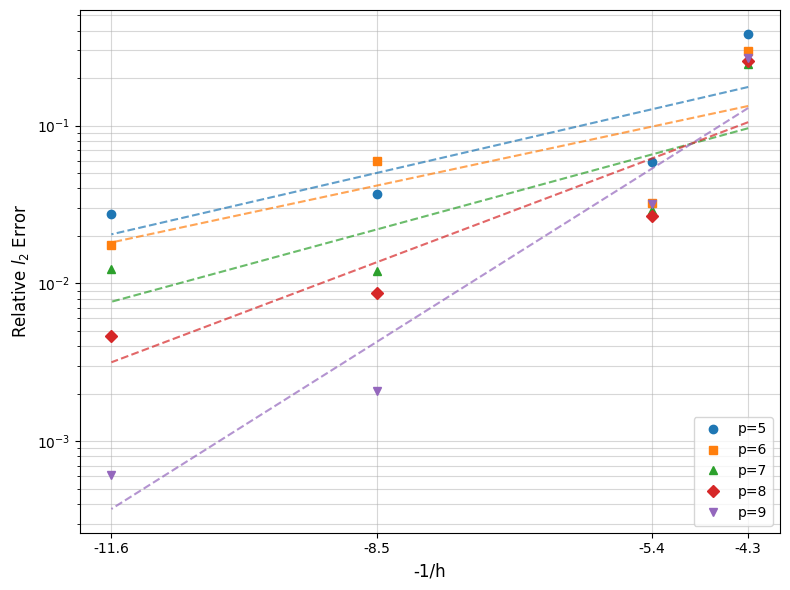

In [96]:
markers = ['o', 's', '^', 'D', 'v']  
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = [f'p={start_order+0}', f'p={start_order+1}', f'p={start_order+2}', f'p={start_order+3}',f'p={start_order+4}']
plt.figure(figsize=(8, 6))

for i in range(end_order-start_order):
    h = HH[i, :]
    e = EE[i, :]
    x = -1.0 / h   # -1/h
    slope, intercept = np.polyfit(x, np.log(e), 1)
    fit_e = np.exp(intercept + slope * x)
    plt.semilogy(
        x, e,
        marker=markers[i],
        linestyle='None',
        color=colors[i],
        label=f'{labels[i]}'
    )
    plt.semilogy(
        x, fit_e,
        linestyle='--',
        color=colors[i],
        alpha=0.7,
        linewidth=1.5
    )

ax = plt.gca()
xticks = -np.unique(1.0 / HH.ravel())
xticks = xticks[np.isfinite(xticks)]
xticks = np.sort(xticks)
ax.set_xticks(xticks)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.1f}"))
plt.xlabel('-1/h', fontsize=12)
plt.ylabel('Relative $l_2$ Error', fontsize=12)
ax.xaxis.set_minor_locator(ticker.NullLocator())
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('./result/helm3d_rfmfd_pou_p=56789_convergence_scatter_Hfixed_exp.eps', bbox_inches='tight')
plt.show()


# operator learning

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import qmc
# =========================================================
# 1. star-shaped boundary
# =========================================================
def rQ(theta, phi):
    return np.sqrt(
        1
        + np.sin(2 * np.sin(phi) * np.cos(theta))**2
        * np.sin(2 * np.sin(phi) * np.sin(theta))**2
        * np.sin(2 * np.cos(phi))**2
    )
# =========================================================
# 2. inside test
# =========================================================
def inside_star(x, y, z, eps=1e-12):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arctan2(y, x)
    phi = np.arccos(np.clip(z / (r + eps), -1, 1))
    return r <= rQ(theta, phi)

def filter_centers_by_boundary(C, X_boundary, R):
    tree = cKDTree(X_boundary)
    dist, _ = tree.query(C, k=1)  # distance to boundary
    mask = dist <= R
    return C[mask], mask
# =========================================================
# 3. generate boundary points
# =========================================================
def generate_boundary_points(N_boundary=2000):
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_boundary)
    theta = 2 * np.pi * pts[:, 0]
    phi = np.arccos(1 - 2 * pts[:, 1])
    r = rQ(theta, phi)
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    return np.vstack([x, y, z]).T
# =========================================================
# 4. generate patch centers
# =========================================================
def generate_centers(N_patch_grid, margin=0.1):
    grid = np.linspace(-1 - margin, 1 + margin, N_patch_grid)
    X, Y, Z = np.meshgrid(grid, grid, grid)
    C = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
    return C
# =========================================================
# 5. compute uniform R via overlap + boundary
# =========================================================
def compute_R_from_overlap(C, gamma=0.5, k=10):
    tree = cKDTree(C)
    dist, _ = tree.query(C, k=k+1)
    h = np.median(dist[:, -1])
    # overlap condition: dist <= 2R * gamma
    R = h / (2 * gamma)
    return R

# =========================================================
# 6. generate inner points via patch + filter
# =========================================================
def generate_inner_points(C, R, N_local=150):
    X_list = []
    for c in C:
        sampler = qmc.Halton(d=3, scramble=False)
        pts = sampler.random(N_local)
        u, v, w = pts[:, 0], pts[:, 1], pts[:, 2]
        theta = 2 * np.pi * u
        phi = np.arccos(1 - 2 * v)
        r = R * (w ** (1/3))
        x = c[0] + r * np.sin(phi) * np.cos(theta)
        y = c[1] + r * np.sin(phi) * np.sin(theta)
        z = c[2] + r * np.cos(phi)
        X_list.append(np.vstack([x, y, z]).T)
    X_raw = np.vstack(X_list)
    # ======= 关键：投影回 star domain =======
    mask = inside_star(
        X_raw[:, 0],
        X_raw[:, 1],
        X_raw[:, 2]
    )
    X_inner = X_raw[mask]
    return X_inner
# =========================================================
# 7. 可视化函数
# =========================================================
def visualize_points(X_inner, X_boundary):

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    # ==========================
    # 1. 生成参考边界（仅用于 wireframe）
    # ==========================
    n_theta = 60
    n_phi = 60
    theta = np.linspace(0, 2*np.pi, n_theta)
    phi = np.linspace(0, np.pi, n_phi)
    theta, phi = np.meshgrid(theta, phi)
    r = rQ(theta, phi)
    X = r * np.sin(phi) * np.cos(theta)
    Y = r * np.sin(phi) * np.sin(theta)
    Z = r * np.cos(phi)
    ax.plot_wireframe(
        X, Y, Z,
        rstride=2, cstride=2,
        color='black',
        linewidth=0.5,
        alpha=0.8,
        zorder=0.5
    )
    # ==========================
    # 2. Boundary 点
    # ==========================
    ax.scatter(
        X_boundary[:, 0],
        X_boundary[:, 1],
        X_boundary[:, 2],
        s=1,
        color='blue',
        depthshade=True,
        zorder=2,
        label='Boundary points'
    )
    # ==========================
    # 3. 内点
    # ==========================
    ax.scatter(
        X_inner[::2, 0],
        X_inner[::2, 1],
        X_inner[::2, 2],
        s=1,
        color='red',
        alpha=0.7,
        depthshade=True,
        zorder=3,
        label='Interior points'
    )
    # ==========================
    # 4. 视觉设置
    # ==========================
    ticks = [-1, -0.5, 0, 0.5, 1]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    ax.view_init(elev=35, azim=45)
    plt.tight_layout()
    plt.show()

# =========================================================
# 8. main
# =========================================================
def generator_points_3d_overlap(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap,
    visu
):

    X_boundary = generate_boundary_points(N_boundary)

    # =====================================================
    # 1. raw centers
    # =====================================================
    C_raw = generate_centers(N_patch_grid, margin=0.1)

    # =====================================================
    # 2. filter by boundary distance
    # =====================================================
    # temporary R just for filtering
    R_tmp = compute_R_from_overlap(C_raw, gamma=overlap, k=10)
    C, mask = filter_centers_by_boundary(C_raw, X_boundary, R_tmp)
    print("Generator's C:", len(C))
    # =====================================================
    # 3. IMPORTANT: recompute R using FINAL C
    # =====================================================
    R = compute_R_from_overlap(C, gamma=overlap, k=10)
    print("Generator's R =", R)
    # =====================================================
    # 4. inner points
    # =====================================================
    X_inner = generate_inner_points(C, R, N_local_per_patch)
    print("X_inner:", len(X_inner))
    print("X_boundary:", len(X_boundary))
    R = R * np.ones(len(C))
    # =====================================================
    # 5. visualization
    # =====================================================
    if visu:
        visualize_points(X_inner, X_boundary)

    return X_inner, X_boundary, C, R

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))


# N_patch_grid = 5
# N_local_per_patch = 200
# N_boundary = 1500
# overlap = 0.6
# visu = True
# X_inner, X_boundary, C, R = generator_points_3d_overlap(N_patch_grid,N_local_per_patch,N_boundary,overlap,visu)
# dists = np.linalg.norm(X_inner[:, None, :] - X_inner[None, :, :], axis=-1)
# h = fill_distance(X_inner)
# print("填充间距:", h)

import numpy as np
from scipy.spatial import cKDTree

def estimate_uniform_R_from_target_n(X, target_n, safety=1.1):
    """
    根据目标 patch 内点数 target_n，估计统一半径 R。
    用每个点到第 target_n 个邻居的距离，再取中位数。
    """
    tree = cKDTree(X)
    target_n = min(target_n, X.shape[0])
    dists, _ = tree.query(X, k=target_n, workers=-1)
    if target_n == 1:
        r_each = dists
    else:
        r_each = dists[:, -1]
    R = safety * np.median(r_each)
    return R

def generate_centers_from_R(X, R, delta=0.2, margin=0.1):
    """
    根据统一半径 R 生成规则 Cartesian patch centers。
    3D 中:
        R = (1 + delta) * sqrt(3) * H / 2
    所以:
        H = 2R / ((1 + delta) sqrt(3))
    """
    H = 2.0 * R / ((1.0 + delta) * np.sqrt(3.0))
    xmin, ymin, zmin = X.min(axis=0) - margin
    xmax, ymax, zmax = X.max(axis=0) + margin
    gx = np.arange(xmin, xmax + H, H)
    gy = np.arange(ymin, ymax + H, H)
    gz = np.arange(zmin, zmax + H, H)
    Xg, Yg, Zg = np.meshgrid(gx, gy, gz, indexing="ij")
    C_all = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T
    return C_all, H



def filter_centers_touching_X(C_all, X, R):
    """
    只保留半径 R 内至少包含一个 X 点的 patch center。
    """
    tree_X = cKDTree(X)
    keep = []
    for i, c in enumerate(C_all):
        idx = tree_X.query_ball_point(c, R)
        if len(idx) > 0:
            keep.append(i)
    return C_all[np.array(keep, dtype=int)]


def check_patch_cover_and_counts(C, R, X):
    """
    因为 X=Y，所以检查所有 X 是否被至少一个 patch 覆盖，
    并统计每个 patch 内点数。
    """
    tree_C = cKDTree(C)
    cover_lists = tree_C.query_ball_point(X, R)
    cover_count = np.array([len(v) for v in cover_lists])
    uncovered = np.where(cover_count == 0)[0]
    tree_X = cKDTree(X)
    nX = np.array([len(tree_X.query_ball_point(c, R)) for c in C])
    print("========== Patch report ==========")
    print("num patches:", len(C))
    print("R =", R)
    print("uncovered X:", len(uncovered), "/", len(X))
    print("cover count min/mean/max:",
          cover_count.min(), cover_count.mean(), cover_count.max())
    print("patch nX min/mean/max:",
          nX.min(), nX.mean(), nX.max())
    return uncovered, cover_count, nX

def generate_patches_X_equals_Y(
    X,
    target_n=120,
    delta=0.2,
    safety=1.1,
    margin=0.1,
    max_iter=10
):
    """
    X=Y 情况下，根据每个 patch 目标点数 target_n 生成 C 和统一 R。
    """
    X = np.asarray(X)
    # 1. 由目标点数估计统一半径
    R = estimate_uniform_R_from_target_n(
        X,
        target_n=target_n,
        safety=safety
    )
    for it in range(max_iter):
        print(f"\n--- iter {it} ---")

        # 2. 由 R 反推中心网格
        C_all, H = generate_centers_from_R(
            X,
            R,
            delta=delta,
            margin=margin
        )
        # 3. 保留和 X 有交集的 patch
        C = filter_centers_touching_X(C_all, X, R)
        # 4. 检查覆盖
        uncovered, cover_count, nX = check_patch_cover_and_counts(C, R, X)
        print("H =", H)
        print("target_n =", target_n)
        print("mean nX / target_n =", nX.mean() / target_n)
        if len(uncovered) == 0:
            break
        # 如果没覆盖完整，扩大半径
        R *= 1.05
    R_vec = R * np.ones(len(C))
    info = {
        "R": R,
        "H": H,
        "delta": delta,
        "num_patches": len(C),
        "target_n": target_n,
        "nX_min": nX.min(),
        "nX_mean": nX.mean(),
        "nX_max": nX.max(),
        "cover_min": cover_count.min(),
        "cover_mean": cover_count.mean(),
        "cover_max": cover_count.max(),
        "uncovered": len(uncovered),
    }
    return C, R_vec, info


def remove_empty_patches(C, R, X_inner, X_boundary):
    """
    去掉球内没有任何 X_inner 或 X_boundary 的 patch centers.
    C: (Np, 3)
    R: (Np,) 或 scalar
    """
    C = np.asarray(C)
    R = np.asarray(R)
    X_all = np.vstack([X_inner, X_boundary])
    tree_X = cKDTree(X_all)
    keep = []
    for j, c in enumerate(C):
        rj = R[j] if R.ndim > 0 else R
        idx = tree_X.query_ball_point(c, rj)
        if len(idx) > 0:
            keep.append(j)
    keep = np.array(keep, dtype=int)
    C_new = C[keep]
    R_new = R[keep] if R.ndim > 0 else R * np.ones(len(C_new))
    print("original patches:", len(C))
    print("kept patches:", len(C_new))
    print("removed patches:", len(C) - len(C_new))
    return C_new, R_new, keep



import numpy as np
import torch
import torch.nn as nn
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.spatial import KDTree, distance
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve,splu, eigs, LinearOperator, svds
from scipy.linalg import lstsq, lu_factor, lu_solve
from scipy.sparse import csc_matrix
import matplotlib.ticker as ticker
import time
dtype = torch.float64
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)


import numpy as np
from scipy.spatial import cKDTree

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(2.480142735337281)**2 * x**2)
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, 0, 0)
                    # nn.init.uniform_(m.bias, -torch.pi, -torch.pi)


def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    # plt.savefig('L.eps', bbox_inches='tight')
    plt.show()

def wendland_C2(r):
    return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r)**4

def wendland_C2_derivatives_3d(r, diff, R):
    """
    Delta phi(r_scaled) = 1/R^2 * [phi''(r_scaled)] + 2/r_scaled * phi'(r_scaled)]
    r:    (M, Nc)
    diff: (M, Nc, 3)
    R:    (Nc,)
    """
    eps = 1e-8
    M, Nc = r.shape
    mask = (r < 1).astype(float)
    phi_r_prime  = -20.0 * r * (1.0 - r)**3 * mask
    phi_r_double =  20.0 * (1.0 - r)**2 * (4.0*r - 1.0) * mask
    diff_norm = np.linalg.norm(diff, axis=2)
    diff_norm = np.maximum(diff_norm, eps)
    grad = np.zeros_like(diff)
    lap = np.zeros((M, Nc))
    for j in range(Nc):
        grad[:, j, :] = (
            phi_r_prime[:, j] / (diff_norm[:, j] * R[j])
        )[:, None] * diff[:, j, :]
        lap[:, j] = (
            phi_r_double[:, j]
            + 2.0 * phi_r_prime[:, j] / (r[:, j] + eps)
        ) / (R[j]**2)
    return grad, lap

def shepard_weights_with_derivatives_3d(x, ptch_C, ptch_R):
    """
    x:(M,3) ptch_C:(Np,3), ptch_R:(Np,)
    return
    (M,Np), (M,Np,3), (M,Np)
    """
    eps = 1e-12
    diff = x[:, None, :] - ptch_C[None, :, :]   # (M, Nc, 3)
    r_dist = np.linalg.norm(diff, axis=2)
    r_scaled = r_dist / ptch_R[None, :]
    phi = wendland_C2(r_scaled)
    sum_phi = np.sum(phi, axis=1, keepdims=True)
    sum_phi = np.maximum(sum_phi, 1e-8)
    W = phi / sum_phi
    # ===== 导数 =====
    grad_phi, lap_phi = wendland_C2_derivatives_3d(r_scaled, diff, ptch_R)
    # S = sum_j phi_j
    S = np.sum(phi, axis=1, keepdims=True)           # (M, 1)
    S = np.maximum(S, eps)
    # grad S, lap S
    grad_S = np.sum(grad_phi, axis=1, keepdims=True) # (M, 1, 3)
    lap_S = np.sum(lap_phi, axis=1, keepdims=True)   # (M, 1)
    # W_j = phi_j / S
    W = phi / S                                      # (M, Np)
    # ===== ∇W =====
    # grad W_j = grad_phi_j / S - phi_j grad_S / S^2
    grad_W = (grad_phi / S[:, :, None] - phi[:, :, None] * grad_S / (S[:, :, None] ** 2))
    # ===== ΔW =====
    # lap W_j = lap_phi_j / S - phi_j lap_S / S^2- 2 grad_phi_j · grad_S / S^2 + 2 phi_j |grad_S|^2 / S^3
    grad_phi_dot_grad_S = np.sum(grad_phi * grad_S,axis=2)   # (M, Np)
    grad_S_norm2 = np.sum(grad_S[:, 0, :] ** 2,axis=1,keepdims=True)  
    lap_W = (lap_phi / S- phi * lap_S / (S ** 2)- 2.0 * grad_phi_dot_grad_S / (S ** 2)+ 2.0 * phi * grad_S_norm2 / (S ** 3))
    return W, grad_W, lap_W

def dphi_wrt_y_3d_batch(phi_net, y, X, eps=1e-8):
    """
    1D Parameters
    ----------
    y : (n_j,3) or (1,3)
    X : (K,3)
    
    Returns
    -------
    phi_vals : (n_j, K)
    dphi_dy  : (n_j, K)
    d2phi_dy2: (n_j, K)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    # print("y.shape", y.shape, "X.shape", X.shape)
    y.requires_grad_(False)
    X.requires_grad_(False)
    # =========================================================
    # 1. pairwise difference and Euclidean distance
    # =========================================================
    diff = y[:, None, :] - X[None, :, :]          # (n_j, K, 3)
    r = torch.sqrt((diff ** 2).sum(dim=-1))  # (n_j, K)
    r = r.clamp(min=eps)  
    r.requires_grad_(True)
    # -------- forward --------
    phi_vals = phi_net(r)         # (n_j, K)

    # -------- φ'(r) --------
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True,
    )[0]   # (n_j, K)
    # -------- φ''(r) --------
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=False,
    )[0]   # (n_j, K)
    # 3d laplace
    with torch.no_grad():
        grad_phi = dphi_dr[..., None] * diff / r[..., None]
        lap_phi = d2phi_dr2 + (2.0 / (r)) * dphi_dr
        phi_np = phi_vals.detach().cpu().numpy()
        grad_np = grad_phi.detach().cpu().numpy()
        lap_np = lap_phi.detach().cpu().numpy()
        
    del diff, r, phi_vals, dphi_dr, d2phi_dr2, grad_phi, lap_phi

    if device.type == "cuda":
        torch.cuda.empty_cache()
    return phi_np, grad_np, lap_np


def dphi_wrt_y_3d_chunked(phi_net, Yj, Xj, chunk_size=256):
    phi_list = []
    grad_list = []
    lap_list = []
    for start in range(0, Yj.shape[0], chunk_size):
        end = min(start + chunk_size, Yj.shape[0])
        y_chunk = Yj[start:end]   # (chunk, 3)
        phi, grad, lap = dphi_wrt_y_3d_batch(
            phi_net, y_chunk, Xj
        )
        phi_list.append(phi)
        grad_list.append(grad)
        lap_list.append(lap)
    phi = np.vstack(phi_list)
    grad = np.vstack(grad_list)
    lap = np.vstack(lap_list)
    return phi, grad, lap


def poly3D(Z, order):
    """
    Z: (K, d)
    P: (K, Norder); 
    """
    K = Z.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    P = np.zeros((K, Norder))
    powers = np.arange(order + 1)
    X_pow = Z[:, 0:1] ** powers
    Y_pow = Z[:, 1:2] ** powers
    Z_pow = Z[:, 2:3] ** powers
    cnt = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                P[:, cnt] = X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k]
                cnt += 1        
    return P

def laplacian_poly3D(y, order):
    """
    y: (Np, d)
    lap: (Norder, Np); 
    """
    Np = y.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    lap = np.zeros((Norder, Np))
    
    # 【核心优化】：同样预先计算 0 到 order 的所有幂次
    powers = np.arange(order + 1)
    X_pow = y[:, 0:1] ** powers
    Y_pow = y[:, 1:2] ** powers
    Z_pow = y[:, 2:3] ** powers
    curr = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                val = np.zeros(Np)
                if i >= 2:
                    val += (i * (i - 1)) * (X_pow[:, i - 2] * Y_pow[:, j] * Z_pow[:, k])
                if j >= 2:
                    val += (j * (j - 1)) * (X_pow[:, i] * Y_pow[:, j - 2] * Z_pow[:, k])
                if k >= 2:
                    val += (k * (k - 1)) * (X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k - 2]) 
                lap[curr, :] = val
                curr += 1     
    return lap

def gradient_poly3D(y,order):
    """
    Parameters
    ----------
    y : (M, 3)
    Returns
    -------
    grad_x : (Norder, M)
    grad_y : (Norder, M)
    grad_z : (Norder, M)
    """
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]  # (1,3)
    M = y.shape[0]
    x = y[:, 0]
    yv = y[:, 1]
    z = y[:, 2]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    grad_x = np.zeros((Norder, M))
    grad_y = np.zeros((Norder, M))
    grad_z = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            for k in range(order + 1 - i - j):
                # ∂/∂x
                if i == 0:
                    grad_x[idx, :] = 0.0
                else:
                    grad_x[idx, :] = i * (x ** (i - 1)) * (yv ** j) * (z ** k)
                # ∂/∂y
                if j == 0:
                    grad_y[idx, :] = 0.0
                else:
                    grad_y[idx, :] = j * (x ** i) * (yv ** (j - 1)) * (z ** k)
                # ∂/∂z
                if k == 0:
                    grad_z[idx, :] = 0.0
                else:
                    grad_z[idx, :] = k * (x ** i) * (yv ** j) * (z ** (k - 1))
                idx += 1
    return grad_x, grad_y, grad_z


# (M,1)


In [3]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import spsolve

def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    solve_A = build_wls_solver(A)
    alpha = solve_A(RHS)
    """
    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")
    A = A.tocsr()
    M, N = A.shape
    # -------------------------------------------------
    # weight (computed ONCE)
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 1.0 / (row_max + 1e-12)
    W = sp.diags(w, format='csr')
    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')

    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())

    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        RHSw = w[:, None] * RHS

        Atb = Aw.T @ RHSw
        x = solver(Atb)
        if x.ndim == 1:
            x = x[:, None]
        return x
    return solve

def rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order):
    """
    -Laplace(u) - k^2 u = f, where k^2 = 1
    X:  (N,3)  RBF source points
    Yin: (M1,3) interior points
    Yb:  (M2,3) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0,1,2,3...
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    Y = np.vstack((Yin, Yb))
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    Np = patch_C.shape[0]
    
    f_val =f_func(Yin[:, 0], Yin[:, 1], Yin[:, 2])  if callable(f_func) else f_func #(M1,)
    g_val = g_func(Yb[:, 0], Yb[:, 1], Yb[:, 2]) if callable(g_func) else g_func
    RHS = np.concatenate((f_val, g_val)) #(M,)
    # print("RHS.shape",RHS.shape)
    L = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    O = np.zeros((Norder,Norder))
    # ==============================
    # main loop
    # ==============================
    tree_X = cKDTree(X)
    tree_Y = cKDTree(Y)

    W, grad_W, lap_W= shepard_weights_with_derivatives_3d(Y, patch_C, patch_R)
    # print("W.shape",W.shape)
    grad_Wx, grad_Wy, grad_Wz = grad_W[:,:,0], grad_W[:,:,1], grad_W[:,:,2]

    start = time.time()
    for j in range(Np):
        idx_X = np.array(tree_X.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
        idx_Y = np.array(tree_Y.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
        idx_X.sort()
        idx_Y.sort()
        idx_Yin = idx_Y[idx_Y<M1]
        idx_Yb =  idx_Y[idx_Y>=M1]

        nj   = idx_X.shape[0]
        Mk   = idx_Y.shape[0]
        Mk1  = idx_Yin.shape[0]
        Mk2  = idx_Yb.shape[0]
        Xj   = X[idx_X]
        Yj   = Y[idx_Y]
        Yj_in = Y[idx_Yin]
        # print(idx_Y.shape,idx_X.shape, idx_Yb.shape)
        dist_ZZ = distance.cdist(Xj, Xj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        # 内存不够, 分块计算导数
        if Yj.shape[0] * Xj.shape[0] >= 2e5:
            phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_chunked(Phi, Yj, Xj, chunk_size=800)
        else:
            phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_batch(Phi, Yj, Xj, eps=1e-8) # (Mk,nj),(Mk,nj,3),(Mk,nj),
        # print("phi_xj",phi_xj.shape,"lap_phi",lap_phi.shape, "grad_phi",grad_phi.shape)
        # if not drop:
        grad_phi_x = grad_phi[:Mk1, :, 0].T  # (nj,Mk1)
        grad_phi_y = grad_phi[:Mk1, :, 1].T  # (nj,Mk1)
        grad_phi_z = grad_phi[:Mk1, :, 2].T  # (nj,Mk1)

        # AP
        P = poly3D(Xj, order) # (nj,Norder)
        # print("Phi_jj.shape",Phi_jj.shape, "P.shape", P.shape)
        AP = np.block([
            [Phi_jj, P],
            [P.T, O]
        ])
        AP += reg * np.eye(nj + Norder)
        
        # RHS_lap, RHS_ide
        p_y = poly3D(Yj, order)                  # (Mk,Norder)
        lap_p = laplacian_poly3D(Yj_in, order)   # (Norder,Mk1)
        # print("p_y.shape",p_y.shape, "lap_p",lap_p.shape)
        RHS_lap = np.concatenate((lap_phi[:Mk1,:], lap_p.T), axis = 1).T  # (nj+Norder,Mk1)
        # print(RHS_lap.shape)
        RHS_ide = np.concatenate((phi_xj, p_y), axis = 1).T       # (nj+Norder,Mk)
        # RHS_grad
        grad_p_x,grad_p_y,grad_p_z = gradient_poly3D(Yj_in, order)  # (Norder,Mk1)
        # if not drop:
        RHS_grad_x = np.concatenate((grad_phi_x, grad_p_x), axis = 0) # (nj+Norder,Mk1)
        RHS_grad_y = np.concatenate((grad_phi_y, grad_p_y), axis = 0) # (nj+Norder,Mk1)
        RHS_grad_z = np.concatenate((grad_phi_z, grad_p_z), axis = 0) # (nj+Norder,Mk1)
        RHS_all = np.concatenate((RHS_lap,RHS_ide,RHS_grad_x,RHS_grad_y,RHS_grad_z),axis=1)       # (nj+Norder,Mk1+Mk+Mk1+Mk1+MK1)
        # else:
        #     RHS_all = np.concatenate((RHS_lap,RHS_ide),axis=1) # (nj+Norder,Mk1+Mk)
        # local operator weight
        LU = lu_factor(AP)
        w_all = lu_solve(LU, RHS_all)                 # (nj + Norder, Mk)
        w_lap = w_all[:, :Mk1]
        w_ide = w_all[:, Mk1:Mk1+Mk]
        # if not drop:
        w_grad_x = w_all[:, Mk1+Mk:2*Mk1+Mk]
        w_grad_y = w_all[:, 2*Mk1+Mk:3*Mk1+Mk]
        w_grad_z = w_all[:, 3*Mk1+Mk:]
        # Shepard weight
        win = W[idx_Yin,j][None, :]  # (1, Mk1)
        # if not drop:
        win_gradx = grad_Wx[idx_Yin,j][None, :]  # (1, Mk1)
        win_grady = grad_Wy[idx_Yin,j][None, :]  # (1, Mk1)
        win_gradz = grad_Wz[idx_Yin,j][None, :]  # (1, Mk1)
        win_lap = lap_W[idx_Yin,j][None, :]      # (1, Mk1)
        # Laplace (nj,Mk1)
        # if not drop:
        Laplace = (2 * win_gradx * w_grad_x[:nj,:Mk1]+ 2 * win_grady * w_grad_y[:nj,:Mk1] + 2 * win_gradz * w_grad_z[:nj,:Mk1] + win * w_lap[:nj,:Mk1] + win_lap * w_ide[:nj,:Mk1])  # (nj, Mk_1)
        # else: 
        # Laplace =  win * w_lap[:nj,:Mk1]
        I = win * w_ide[:nj,:Mk1]          # (nj, Mk1)
        # --- boundary condtion
        wbc = W[idx_Yb,j][None, :]     # (1, Mk2)
        Op_bc = wbc * w_ide[:nj,Mk1:]  # (nj, Mk2)
        # --- LI 
        wvec = W[idx_Y, j][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]      # (nj,Mk)

        L[np.ix_(idx_Yin, idx_X)] = L[np.ix_(idx_Yin, idx_X)] - Laplace.T - I.T
        L[np.ix_(idx_Yb, idx_X)] = L[np.ix_(idx_Yb, idx_X)] + Op_bc.T
        
        LI[np.ix_(idx_Y, idx_X)] = LI[np.ix_(idx_Y, idx_X)] + IDE.T

    end = time.time()
    print("Compile derivative matrix time =", end - start, "seconds")
        
    L = L.tocsc()
    LI = LI.tocsc()
    # cond_L = np.linalg.cond(L.tocsr().todense())
    # print(f" L's condition number:, {cond_L}")
    # cond_LI = np.linalg.cond(LI.tocsr().todense())
    # print(f" LI's condition number:, {cond_LI}")
    # spy_like_matlab(L)
    # ==============================
    # solve
    # ==============================

    if M == N:
        LU1 = splu(L, permc_spec='COLAMD')
        UX = LU1.solve(RHS)
    else:
        # least squares: solve column by column
        solve_L = build_wls_solver(L)
        UX = solve_L(RHS).squeeze(-1)
        print(UX.shape)
        # Q, R = np.linalg.qr(L.toarray(), mode='reduced')
        # UX = np.linalg.solve(R, Q.T @ RHS)
    # -------------------------
    # Evaluate at Y
    # -------------------------
    UY = LI @ UX # (M,Q)

    return UY[:,None],LI,L


def test_solver(L, LI, RHS):
    """
    L  : (M,N) sparse operator matrix
    LI : (M,N) sparse interpolation matrix
    RHS: (M,Q) numpy array

    Returns
    -------
    UY : (M,Q) numpy array
    """
    L = L.tocsr()
    LI = LI.tocsr()

    M, N = L.shape
    Q = RHS.shape[1]
    # -------------------------
    # Solve L UX = RHS
    # -------------------------
    if M == N:
        # spsolve supports multiple RHS
        UX = spsolve(L, RHS)          # (N,Q)
    else:
        # least squares: solve column by column
        solve_L = build_wls_solver(L)
        UX = solve_L(RHS) # (N,Q)
        print(UX.shape)
        # Q, R = np.linalg.qr(L.toarray(), mode='reduced')
        # UX = np.linalg.solve(R, Q.T @ RHS)
    # -------------------------
    # Evaluate at Y
    # -------------------------
    UY = LI @ UX # (M,Q)

    return UY


In [4]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double()

u_func = lambda x, y, z: np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
g_func = lambda x, y, z: u_func(x, y, z)
# #===========================================================
# data = np.load('./data/orig_nodes_results_on_X_generated_by_overlap.npz') #coords, interior_idx, boundary_idx, u_new, f_new  
data = np.load('./data/orig_nodes_results_on_X_generated_by_overlap.npz') #coords, interior_idx, boundary_idx, u_new, f_new  


p, f_new, u_new, index_in, index_bc = data['coords'],data['f_new'],data['u_new'],data['interior_idx'],data['boundary_idx']  # sigma2 = 0.1, l = 0.15
index_in, index_bc = index_in.reshape(-1), index_bc.reshape(-1)
# print(index_in)
# print(p.shape,f_new.shape) # (21523, 3) (21523, 100)
# print(index_in.shape, index_bc.shape) #(11142,) (10381,)

torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]
M1 = M - M2

testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_func = f_new[index_in,testnum]
print("f_func.shape",f_func.shape)


u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
print("u_true's shape",u_true.shape)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
# X = p
torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 150
N_boundary = 3000
overlap = 0.6

# generate points
X_inner, X_boundary, C, R = generator_points_3d_overlap(
        N_patch_grid,
        N_local_per_patch,
        N_boundary,
        overlap,
        False
    )
X = np.vstack([X_inner, X_boundary])

K = 150
C_pou, R_pou, info = generate_patches_X_equals_Y(X, target_n= K,delta=0.2,
                                                safety=1.1,margin=0.1)
ptch = {
    "C": C_pou,
    "R": R_pou
}

reg = 1e-12
order = 6

# # ===========================================================
start = time.time()
UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
end = time.time()
print("Time for solving Helm =", end - start, "seconds")
print(u_true.shape,UY.shape)
error = np.abs(UY- u_true)[:M1,:] 
error_bc = np.abs(UY- u_true)[M1:,:]
print(f"error on boundary is  {error_bc.max().item():.3e}")
print(f'p = {order}; L infity error in u_rfmfd_pou: {error.max().item():.3e}')
error_u = relative_l2(UY[:M1,:] ,u_true[:M1,:])
print(f'p = {order}; Relative L2 error in u_rfmfd_pou: {error_u.item():.3e}')


f_func.shape (9031,)
u_true's shape (15031, 1)
Generator's C: 119
Generator's R = 0.6481812160876687
X_inner: 4552
X_boundary: 3000

--- iter 0 ---
========== Patch report ==========
num patches: 275
R = 0.37272421430479624
uncovered X: 0 / 7552
cover count min/mean/max: 2 4.805349576271187 8
patch nX min/mean/max: 17 131.96363636363637 247
H = 0.3586540424372765
target_n = 150
mean nX / target_n = 0.8797575757575757


/home/chengwu/.conda/envs/py312/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Compile derivative matrix time = 13.285479307174683 seconds
(7552,)
Time for solving Helm = 38.258482933044434 seconds
(15031, 1) (15031, 1)
error on boundary is  5.564e-03
p = 6; L infity error in u_rfmfd_pou: 7.462e-02
p = 6; Relative L2 error in u_rfmfd_pou: 3.566e-02


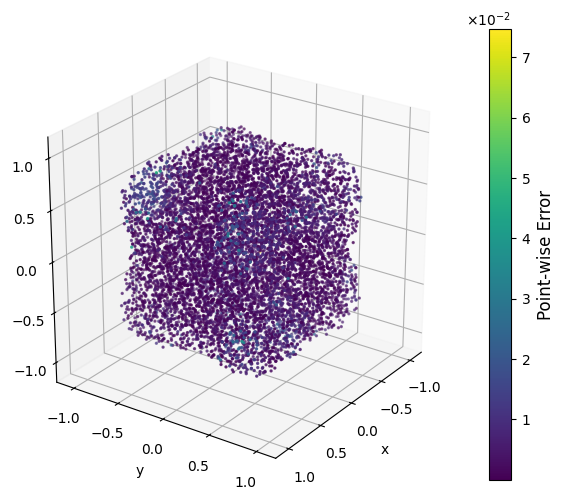

In [5]:
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:M1, 0], Y[:M1, 1], Y[:M1, 2],
    c=error[:,:],
    cmap='viridis',
    s=2
)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
plt.show()

In [6]:
import time
E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_vec = f_new[index_in,:] 
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)
RHS = np.concatenate([f_vec,g_vec],axis = 0 )

start_time = time.time()
UY = test_solver(L, LI, RHS)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")

error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

np.random.seed(100)
q = np.random.randint(0,100)

import matplotlib.colors as mcolors

v_min = min(u_true[:, q].min(), UY[:, q].min())
v_max = max(u_true[:, q].max(), UY[:, q].max())
norm = mcolors.Normalize(vmin=v_min, vmax=v_max)

(15031, 100) (9031, 100) (6000, 100)
(7552, 100)
p = 6, inference time: 24.8766 秒


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


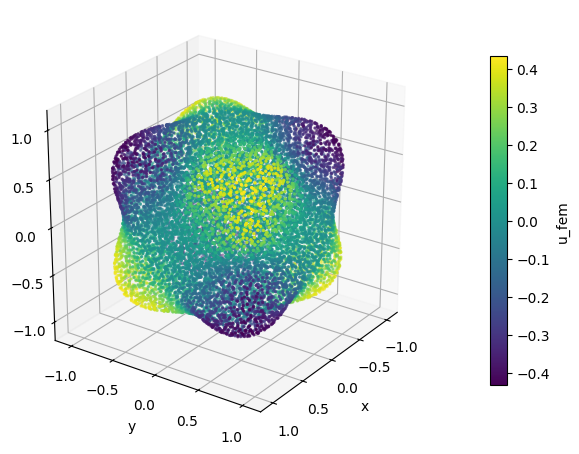

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


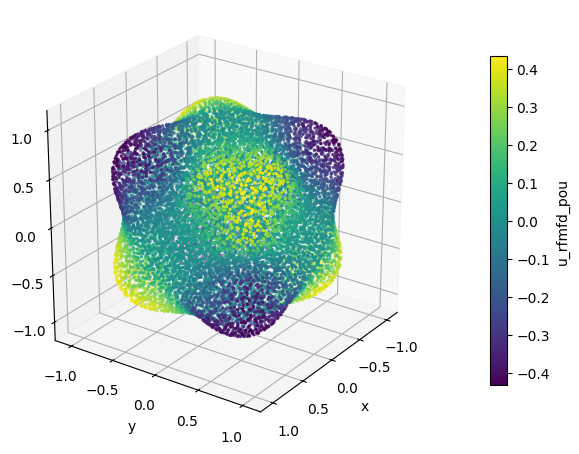

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


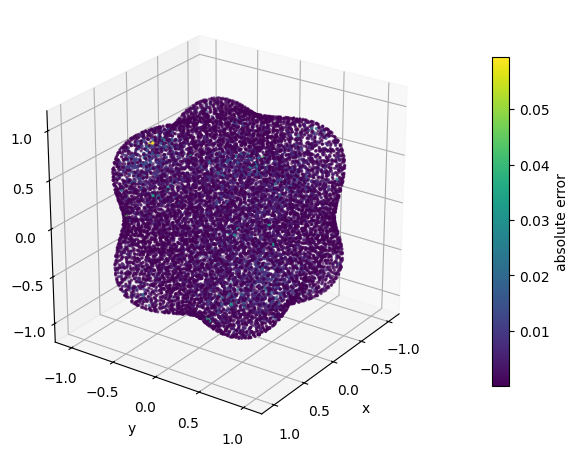

p = 6, test on 100 samples. The mean of max error: 6.134151e-02, and mean of relative L2 error: 2.148806e-02
p = 6, test on 100 samples. The variance of max error: 1.148737e-04, and variance of relative L2 error: 8.821820e-07


In [9]:
# plot_3d_scalar
# u_fem

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=u_true[:, q].reshape(-1),
    cmap='viridis',
    s=2
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label('u_fem')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
fig.savefig(f'./result/helm3d_rfmfdpou_p={order}_u_fem.eps', bbox_inches='tight')
plt.show()

# u_rfmfd_pou
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=UY[:, q].reshape(-1),
    cmap='viridis',
    s=2
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label('u_rfmfd_pou')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
fig.savefig(f'./result/helm3d_rfmfdpou_p={order}_u_rfm_fd_pou.eps',bbox_inches='tight')

plt.show()

# absolute error
error_inf = np.abs(UY - u_true)
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=error_inf[:, q].reshape(-1),
    cmap='viridis',
    s=2
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label('absolute error')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
fig.savefig(f'./result/helm3d_rfmfdpou_p={order}_absolute_error.eps', bbox_inches='tight')
plt.show()
print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")
